# Modeling earthquake cycle time series
The earth moves both during and inbetween earthquakes and we can observe this motion geodetically.  Our goal is to use this information to constrain the time-dependent parameters of a fault model.
1. Long-term slow deformation that may change slope or be slighly curved.  May have jumps at the time of earthquakes
2. Jumps at the times of earthquakes
3. Relatively rapid (and generally decaying) deformation after earthquakes
4. Small magnitude accelerations and decelerations

# Current models
- Kalman filter
- Kalman filter with NNLS solver
- Various semi-working Interacting Multiple Models (IMM)
- Particle filter that works well for modle but not fault model
- Kalman filter with no coseismic jumps

# Goals
- Tuned IMM filter (2 state?, 3+ state?)
- Tuned Particle filter

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import nnls
from scipy.linalg import inv
%config InlineBackend.figure_format = "retina"

# Observation coordinates
- Should probably make non-symetric because the symmetry adds nothing

In [4]:
# Define observation coordinates
n_pts = 50
x_lim = 50
x = np.linspace(-x_lim, x_lim, n_pts)

# Velocity partials for two slip patches and a deep dislocation

In [5]:
def get_velocity(slip_rate, x, locking_depth):
    velocity = slip_rate / np.pi * np.arctan(x / locking_depth)
    return velocity


# Define fault patches
n_patches = 2
min_depth = 1e-10
max_depth = 30
locking_depths = np.linspace(min_depth, max_depth, n_patches + 1)

# Velocities
s = 1.0
v_inter = s / np.pi * np.arctan(x / max_depth)
v_mat = np.zeros((n_patches, n_pts))

# Calculate elastic deformation from each patch
for i in range(len(locking_depths) - 1):
    # Velocity kernel calcuation
    v_upper = get_velocity(1, x, locking_depths[i])
    v_lower = get_velocity(1, x, locking_depths[i + 1])
    v = v_lower - v_upper
    v_mat[i, :] = v

# Generate time series
- One earthquake with slip on the upper patch only
- A deep dislocation with a velocity that changes after an earthquake
- Afterslip on the middle dislocation after the earthquake (decays exponentially)
- Slow slip event on the middle dislocation before earthquake (different time than above)
- Slow slip event on the shallow dislocation before earthquake (different time than above)

In [6]:
# Generate synthetic time series
nt = 100
t_coseismic = 0.5
noise_scale = 0.005
t = np.linspace(0, 1, nt)
dt = t[1] - t[0]
v0 = 0.5 * np.ones(nt)
v1 = np.zeros(nt)
v2 = np.zeros(nt)

# Coseismic jump on upper fault patch
v_coseismic = 25
coseismic_idx = np.argmin(np.abs(t - t_coseismic))
v1[coseismic_idx] = v_coseismic

# Shallow slow slip event before earthquake
sse_amplitude = 3.0
sse_center = 0.35
sse_width = 0.02
v_sse = sse_amplitude * np.exp(-((t - sse_center) ** 2) / (2 * sse_width**2))
v1 += v_sse

# Deep slow slip event before earthquake
sse_amplitude = 1.0
sse_center = 0.25
sse_width = 0.03
v_sse = sse_amplitude * np.exp(-((t - sse_center) ** 2) / (2 * sse_width**2))
v2 += v_sse

# Change interseismic with earthquake
v0[coseismic_idx + 1 : :] = 0.25

# Afterslip on lower fault patch
afterslip_amplitude = 200
# afterslip_amplitude = 0

afterslip_time_scale = 8.0
v2[t > t_coseismic] = afterslip_amplitude * np.exp(
    -afterslip_time_scale * t[t > t_coseismic] - t_coseismic
)

# Assemble linear operator (parameters -> data)
A = np.zeros((n_pts, 3))
A[:, 0] = v_inter
A[:, 1] = -v_mat[0, :]
A[:, 2] = -v_mat[1, :]

x_mat = np.zeros((n_pts, nt))
for i in range(nt):
    # x_mat[:, i] = 0 * v_inter - (v1[i] * v_mat[0, :]) - (v2[i] * v_mat[1, :])
    x_mat[:, i] = v0[i] * v_inter - (v1[i] * v_mat[0, :]) - (v2[i] * v_mat[1, :])

P_true = np.cumsum(x_mat, axis=1) * dt

# Add synthetic noise
P_noise = P_true + noise_scale * np.random.normal(size=P_true.shape)

# Packaging
x0 = np.cumsum(v0)
x1 = np.cumsum(v1)
x2 = np.cumsum(v2)

# Plot position time series
This is conceptually similar to what we'd have in the real world, albeit this synthetic example is a much smaller and simpler data set

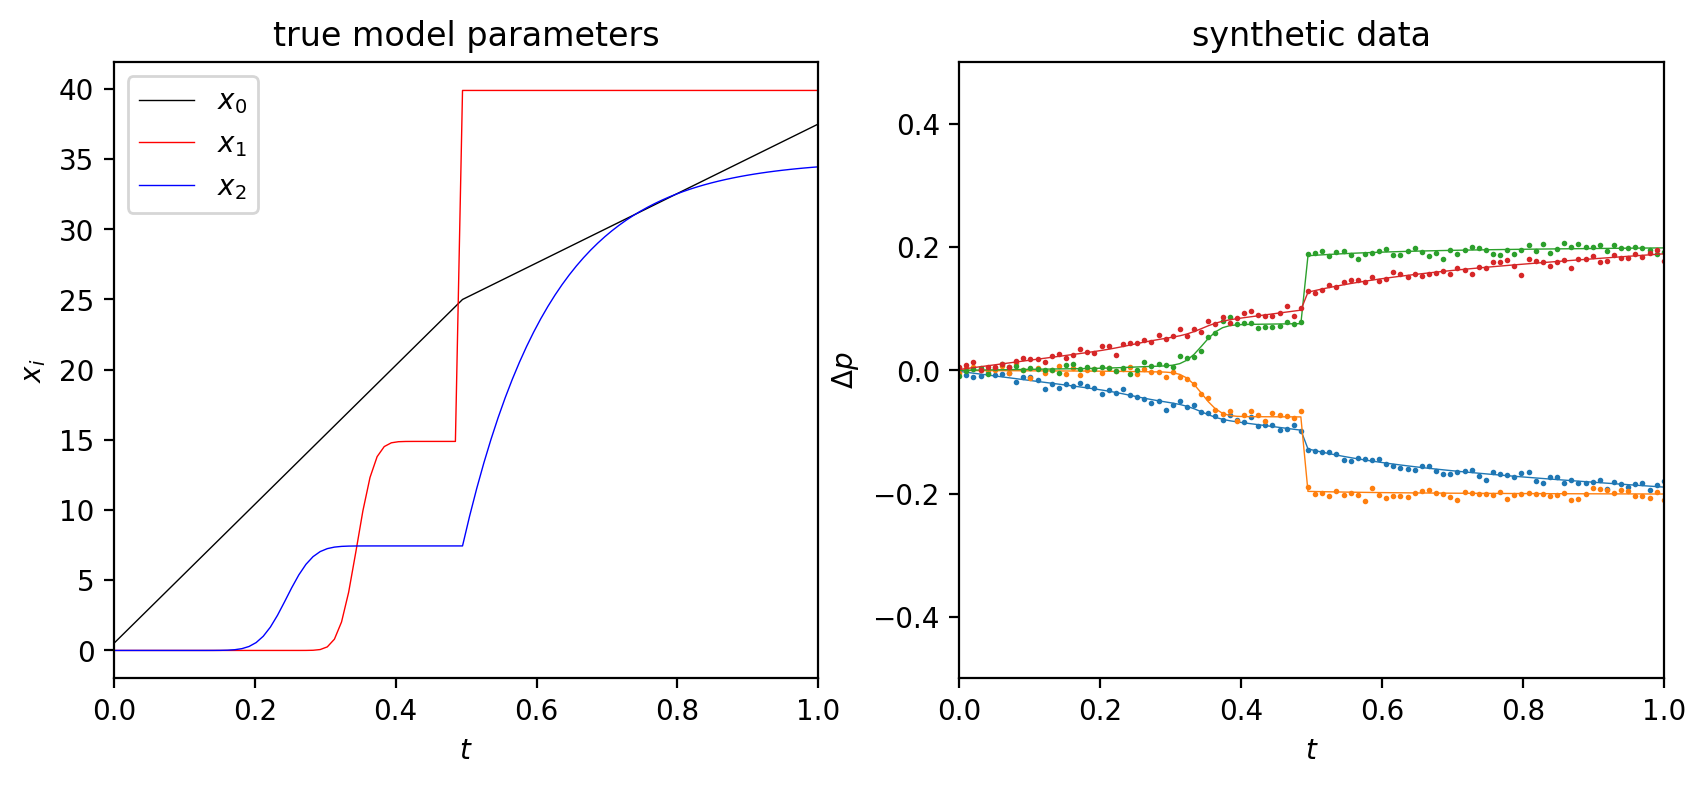

In [7]:
linewidth = 0.5
markersize = 2.0
plot_idx = [5, 24, 26, 45]

# Plot true model parameters
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(t, x0, "-k", label="$x_0$", linewidth=linewidth, markersize=markersize)
plt.plot(t, x1, "-r", label="$x_1$", linewidth=linewidth, markersize=markersize)
plt.plot(t, x2, "-b", label="$x_2$", linewidth=linewidth, markersize=markersize)
plt.xlabel("$t$")
plt.ylabel("$x_i$")
plt.xlim([np.min(t), np.max(t)])
plt.legend()
plt.title("true model parameters")

# Plot synthetic data
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
plt.subplot(1, 2, 2)
for i in range(len(plot_idx)):
    plt.plot(
        t,
        P_true[plot_idx[i], :],
        "-",
        linewidth=linewidth,
        markersize=markersize,
        color=colors[i],
    )
    plt.plot(
        t,
        P_noise[plot_idx[i], :],
        ".",
        linewidth=linewidth,
        markersize=markersize,
        color=colors[i],
    )
plt.xlabel("$t$")
plt.ylabel("$\Delta p$")
plt.xlim([np.min(t), np.max(t)])
plt.ylim([-0.5, 0.5])
plt.title("synthetic data")
plt.show()

# Generate time series with coseismic jump removed ("_noco")

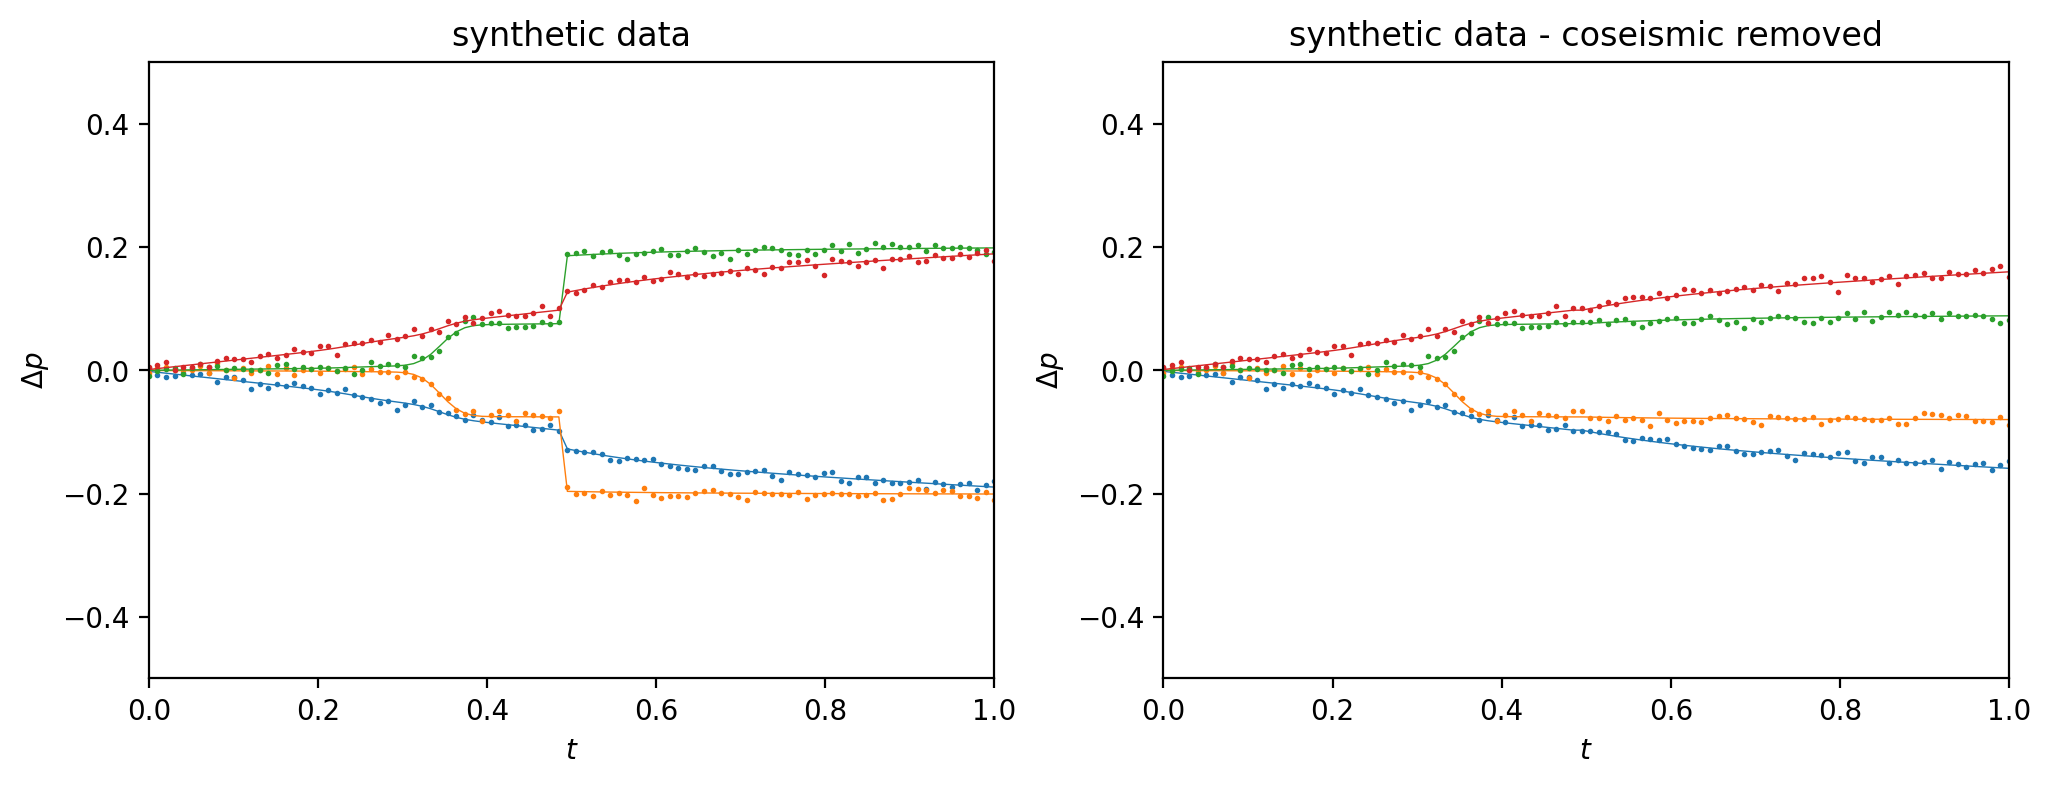

In [ ]:
P_true_noco = np.copy(P_true)
P_noise_noco = np.copy(P_noise)
x1_noco = np.copy(x1)
coseismic_step = x1_noco[coseismic_idx] - x1_noco[coseismic_idx - 1]
x1_noco[coseismic_idx::] -= coseismic_step
x0_noco = np.copy(x0)
x2_noco = np.copy(x2)

for i in range(n_pts):
    # Remove coseismic from noise free observations
    coseismic_step = P_true_noco[i, coseismic_idx] - P_true_noco[i, coseismic_idx - 1]
    P_true_noco[i, coseismic_idx::] -= coseismic_step

    # Remove coseismic from noisy observations
    coseismic_step = P_noise_noco[i, coseismic_idx] - P_noise_noco[i, coseismic_idx - 1]
    P_noise_noco[i, coseismic_idx::] -= coseismic_step

# Plot synthetic data
plt.figure(figsize=(12, 4))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
plt.subplot(1, 2, 1)
for i in range(len(plot_idx)):
    plt.plot(
        t,
        P_true[plot_idx[i], :],
        "-",
        linewidth=linewidth,
        markersize=markersize,
        color=colors[i],
    )
    plt.plot(
        t,
        P_noise[plot_idx[i], :],
        ".",
        linewidth=linewidth,
        markersize=markersize,
        color=colors[i],
    )
plt.xlabel("$t$")
plt.ylabel("$\Delta p$")
plt.xlim([np.min(t), np.max(t)])
plt.ylim([-0.5, 0.5])
plt.title("synthetic data")

plt.subplot(1, 2, 2)
for i in range(len(plot_idx)):
    plt.plot(
        t,
        P_true_noco[plot_idx[i], :],
        "-",
        linewidth=linewidth,
        markersize=markersize,
        color=colors[i],
    )
    plt.plot(
        t,
        P_noise_noco[plot_idx[i], :],
        ".",
        linewidth=linewidth,
        markersize=markersize,
        color=colors[i],
    )
plt.xlabel("$t$")
plt.ylabel("$\Delta p$")
plt.xlim([np.min(t), np.max(t)])
plt.ylim([-0.5, 0.5])
plt.title("synthetic data - coseismic removed")

plt.show()

# Solve for model parameters treating each time step as completely independent

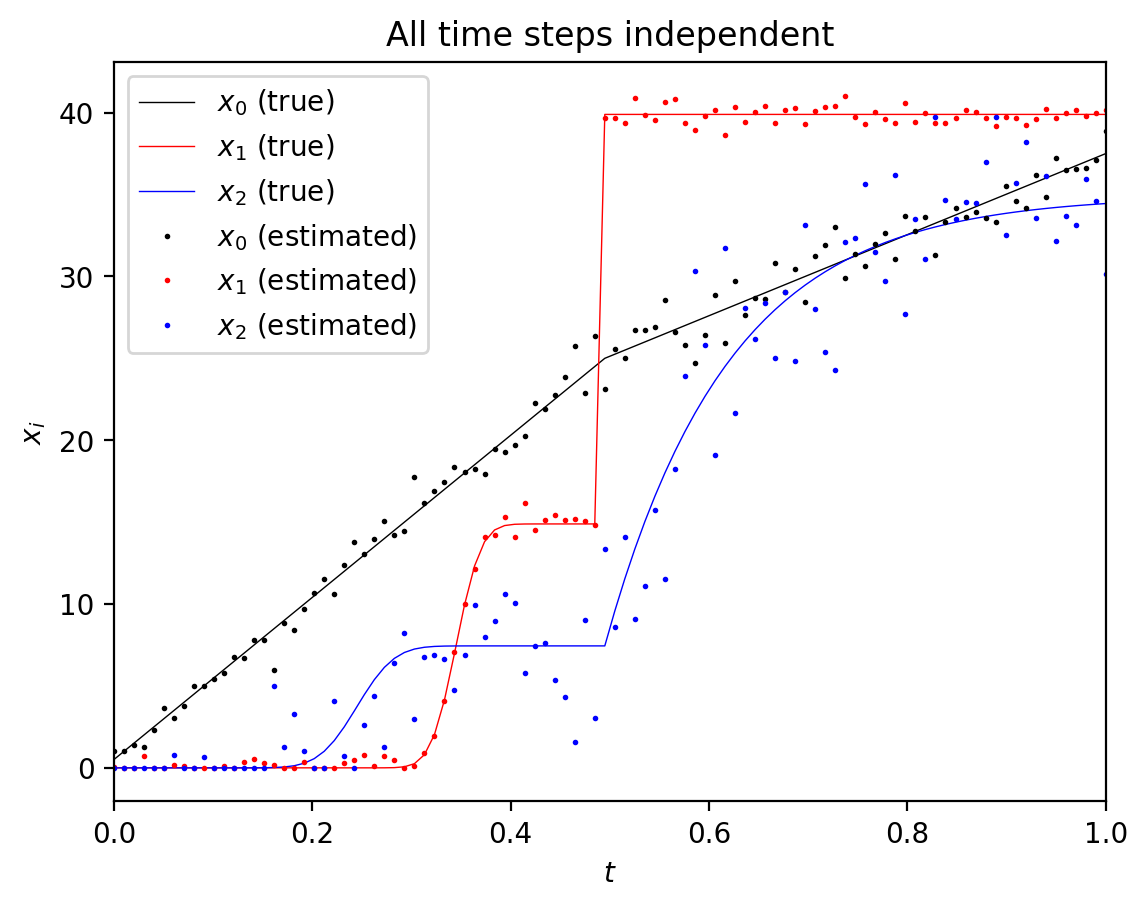

In [6]:
x0_est = np.zeros(nt)
x1_est = np.zeros(nt)
x2_est = np.zeros(nt)

for i in range(nt):
    x, residual = nnls(A, P_noise[:, i] / dt)
    x0_est[i] = x[0]
    x1_est[i] = x[1]
    x2_est[i] = x[2]

plt.figure()
plt.plot(t, x0, "-k", label="$x_0$ (true)", linewidth=linewidth, markersize=markersize)
plt.plot(t, x1, "-r", label="$x_1$ (true)", linewidth=linewidth, markersize=markersize)
plt.plot(t, x2, "-b", label="$x_2$ (true)", linewidth=linewidth, markersize=markersize)
plt.plot(
    t,
    x0_est,
    ".k",
    label="$x_0$ (estimated)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    t,
    x1_est,
    ".r",
    label="$x_1$ (estimated)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    t,
    x2_est,
    ".b",
    label="$x_2$ (estimated)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.xlabel("$t$")
plt.ylabel("$x_i$")
plt.xlim([np.min(t), np.max(t)])
plt.legend()
plt.title("All time steps independent")
plt.show()

# Kalman filter estimation

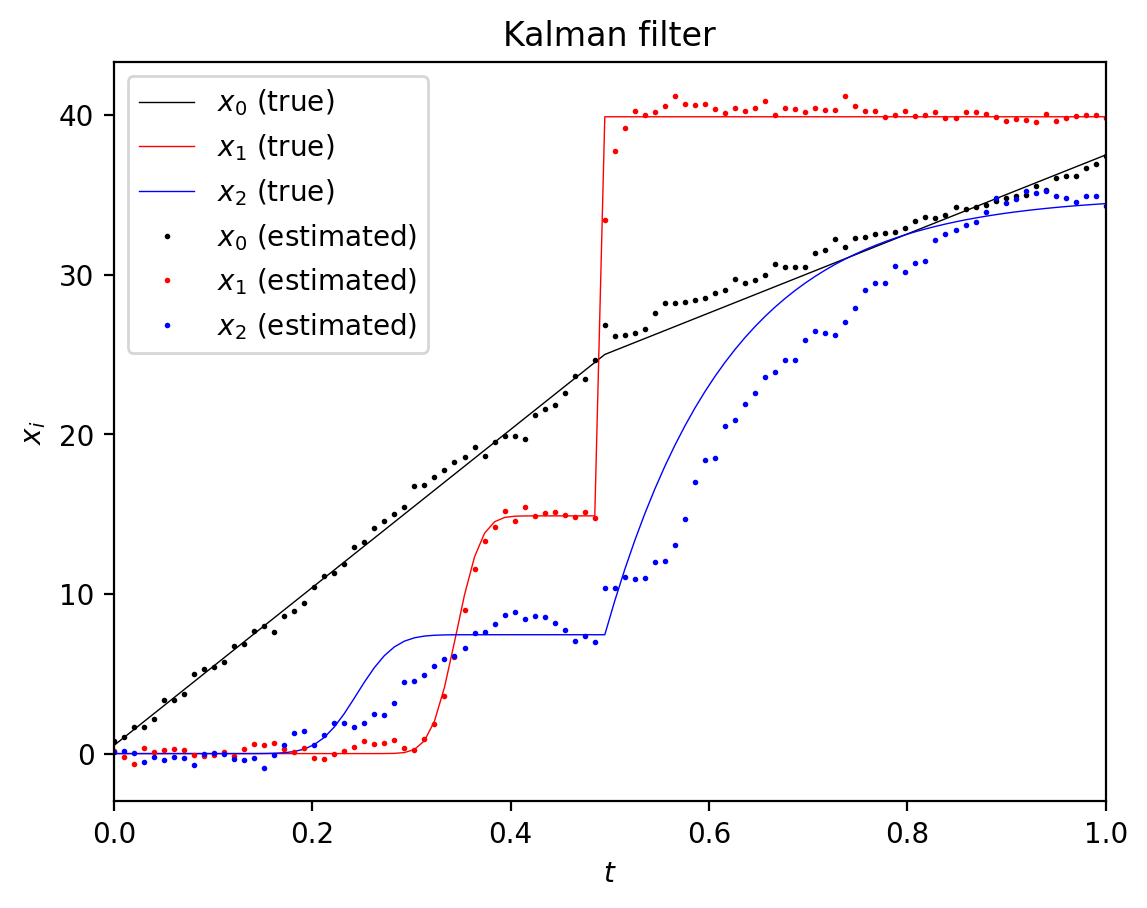

In [7]:
def kalman_filter(times, measurements, H, Q=None, R=None, x0=None, P0=None):
    """
    Kalman filter for parameter estimation through time

    Parameters:
    times: array of time points
    measurements: array of measurements (n_times x n_obs)
    H: observation operator (n_obs x n_states)
    Q: process noise covariance (n_states x n_states)
    R: measurement noise covariance (n_obs x n_obs)
    x0: initial state estimate (n_states)
    P0: initial state covariance (n_states x n_states)

    Returns:
    x_estimates: array of state estimates (n_times x n_states)
    P_estimates: array of state covariances (n_times x n_states x n_states)
    """
    n_times = len(times)
    n_obs = H.shape[0]
    n_states = H.shape[1]

    # Set defaults if not provided
    if Q is None:
        Q = np.eye(n_states) * 1.0
    if R is None:
        R = np.eye(n_obs) * 1.0
    if x0 is None:
        x0 = np.zeros(n_states)
    if P0 is None:
        P0 = np.eye(n_states)

    # State transition matrix (identity for random walk)
    F = np.eye(n_states)

    # Storage for estimates
    x_estimates = np.zeros((n_times, n_states))
    P_estimates = np.zeros((n_times, n_states, n_states))

    # Initialize
    x = x0
    P = P0

    # Run filter through time
    for t, z in enumerate(measurements):
        # Predict
        x = F @ x
        P = F @ P @ F.T + Q

        # Update
        y = z - H @ x
        S = H @ P @ H.T + R
        K = P @ H.T @ inv(S)

        x = x + K @ y
        P = (np.eye(n_states) - K @ H) @ P

        # Store estimates
        x_estimates[t] = x
        P_estimates[t] = P

    return x_estimates, P_estimates


# Example with fault model
x_estimates, P_estimates = kalman_filter(t, P_noise.T, A)

plt.figure()
plt.plot(t, x0, "-k", label="$x_0$ (true)", linewidth=linewidth, markersize=markersize)
plt.plot(t, x1, "-r", label="$x_1$ (true)", linewidth=linewidth, markersize=markersize)
plt.plot(t, x2, "-b", label="$x_2$ (true)", linewidth=linewidth, markersize=markersize)
plt.plot(
    t,
    x_estimates[:, 0] / dt,
    ".k",
    label="$x_0$ (estimated)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    t,
    x_estimates[:, 1] / dt,
    ".r",
    label="$x_1$ (estimated)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    t,
    x_estimates[:, 2] / dt,
    ".b",
    label="$x_2$ (estimated)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.xlabel("$t$")
plt.ylabel("$x_i$")
plt.xlim([np.min(t), np.max(t)])
plt.legend()
plt.title("Kalman filter")
plt.show()

# Kalman filter estimation with non-negative constraint
- The purpose of this is just to show how the KF can work with non-linear constraint step

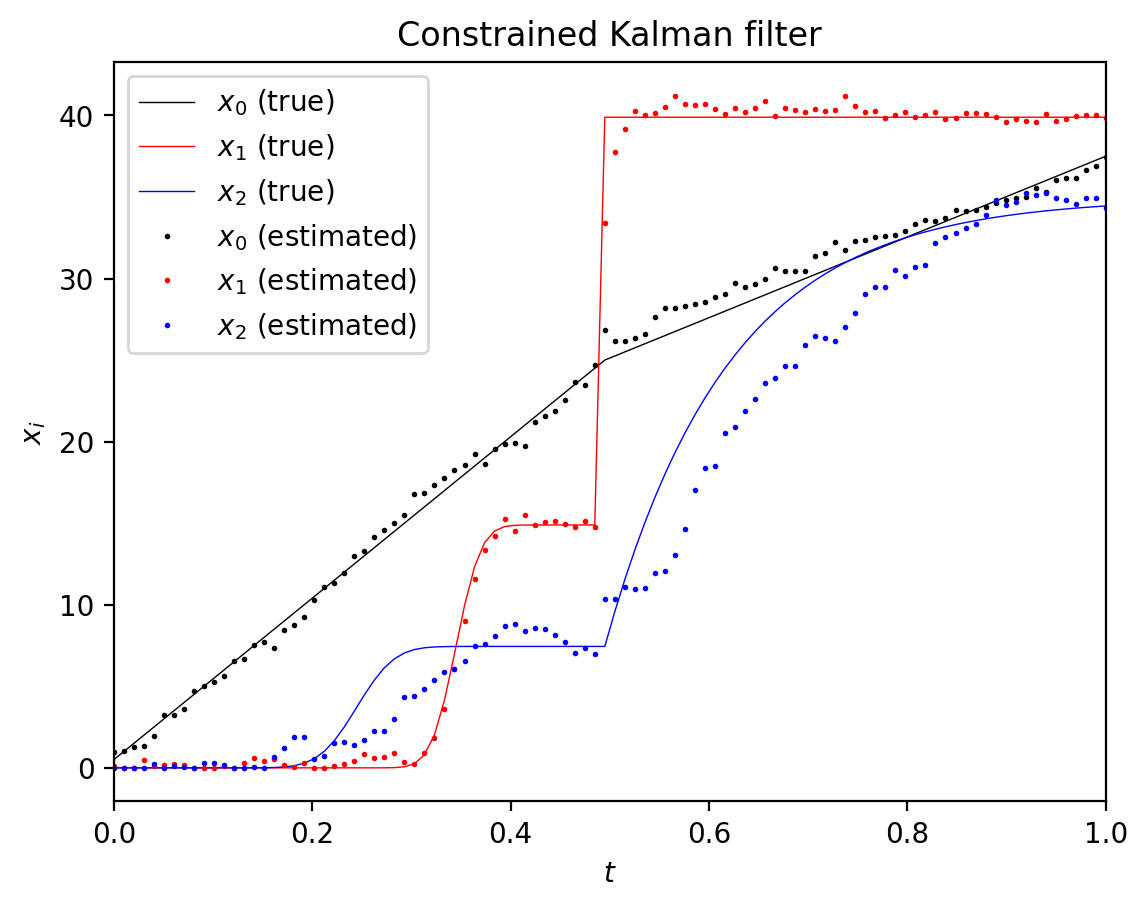

In [8]:
def constrained_kalman_filter(times, measurements, H, Q=None, R=None, x0=None, P0=None):
    """
    Kalman filter with non-negative least squares constraint for parameter estimation

    Parameters:
    times: array of time points
    measurements: array of measurements (n_times x n_obs)
    H: observation operator (n_obs x n_states)
    Q: process noise covariance (n_states x n_states)
    R: measurement noise covariance (n_obs x n_obs)
    x0: initial state estimate (n_states)
    P0: initial state covariance (n_states x n_states)
    """
    n_times = len(times)
    n_obs = H.shape[0]
    n_states = H.shape[1]

    # Set defaults if not provided
    if Q is None:
        Q = np.eye(n_states) * 0.1
    if R is None:
        R = np.eye(n_obs) * 0.1
    if x0 is None:
        x0 = np.zeros(n_states)
    if P0 is None:
        P0 = np.eye(n_states)

    # State transition matrix (identity for random walk)
    F = np.eye(n_states)

    # Storage for estimates
    x_estimates = np.zeros((n_times, n_states))
    P_estimates = np.zeros((n_times, n_states, n_states))

    # Initialize
    x = x0
    P = P0

    # Run filter through time
    for t, z in enumerate(measurements):
        # Predict
        x = F @ x
        P = F @ P @ F.T + Q  # Fixed: correct matrix multiplication

        # Construct weighted least squares problem for the update
        # Transform to standard form incorporating prior
        Rinv_sqrt = inv(np.linalg.cholesky(R))
        Pinv_sqrt = inv(np.linalg.cholesky(P))

        # Stack matrices for the constrained problem
        A_stack = np.vstack([Rinv_sqrt @ H, Pinv_sqrt])

        b_stack = np.concatenate([Rinv_sqrt @ z, Pinv_sqrt @ x])

        # Solve constrained problem with nnls
        x, residual = nnls(A_stack, b_stack)

        # Approximate posterior covariance
        # (using linearized measurement update)
        S = H @ P @ H.T + R
        K = P @ H.T @ inv(S)
        P = (np.eye(n_states) - K @ H) @ P

        # Store estimates
        x_estimates[t] = x
        P_estimates[t] = P

    return x_estimates, P_estimates


x_estimates, P_estimates = constrained_kalman_filter(t, P_noise.T, A)

plt.figure()
plt.plot(t, x0, "-k", label="$x_0$ (true)", linewidth=linewidth, markersize=markersize)
plt.plot(t, x1, "-r", label="$x_1$ (true)", linewidth=linewidth, markersize=markersize)
plt.plot(t, x2, "-b", label="$x_2$ (true)", linewidth=linewidth, markersize=markersize)
plt.plot(
    t,
    x_estimates[:, 0] / dt,
    ".k",
    label="$x_0$ (estimated)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    t,
    x_estimates[:, 1] / dt,
    ".r",
    label="$x_1$ (estimated)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    t,
    x_estimates[:, 2] / dt,
    ".b",
    label="$x_2$ (estimated)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.xlabel("$t$")
plt.ylabel("$x_i$")
plt.xlim([np.min(t), np.max(t)])
plt.legend()
plt.title("Constrained Kalman filter")
plt.show()

Estimation with jump aware Kalman filter

JUMP DETECTED
0.19656894634034608


/var/folders/pq/qqjshcd51vg5t9w5ws8wkmw00000gn/T/ipykernel_32329/3169023947.py:46: RuntimeWarning: invalid value encountered in sqrt
  maha_dist = np.sqrt(innovation.T @ inv(S) @ innovation)


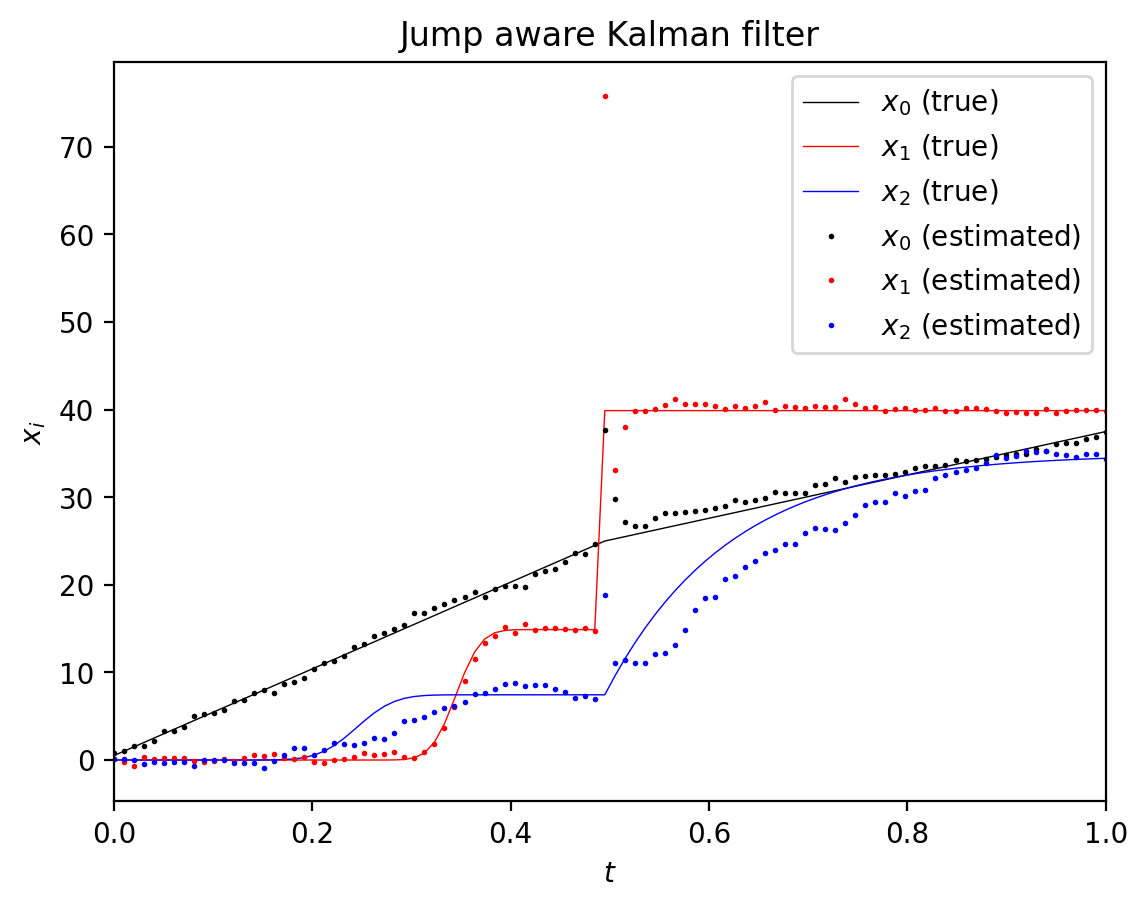

In [20]:
def detect_jump(innovation, S, threshold=3.0):
    """
    Detect jumps using Mahalanobis distance
    """
    maha_dist = np.sqrt(innovation.T @ inv(S) @ innovation)
    return maha_dist > threshold


def jump_aware_kalman_filter(times, measurements, H, Q=None, R=None, x0=None, P0=None):
    """
    Kalman filter with jump detection and handling
    """
    n_times = len(times)
    n_obs = H.shape[0]
    n_states = H.shape[1]

    # Set defaults if not provided
    if Q is None:
        Q = np.eye(n_states) * 1.0
    if R is None:
        R = np.eye(n_obs) * 1.0
    if x0 is None:
        x0 = np.zeros(n_states)
    if P0 is None:
        P0 = np.eye(n_states)

    # State transition matrix (identity for random walk)
    F = np.eye(n_states)

    # Storage for estimates
    x_estimates = np.zeros((n_times, n_states))
    P_estimates = np.zeros((n_times, n_states, n_states))

    # Initialize
    x = x0
    P = P0
    for t, z in enumerate(measurements):
        # Predict
        x = F @ x
        P = F @ P @ F.T + Q

        # Check for jump
        innovation = z - H @ x
        S = H @ P @ H.T + R

        maha_dist = np.sqrt(innovation.T @ inv(S) @ innovation)
        if maha_dist > 0.1:
            print("JUMP DETECTED")
            print(maha_dist)
            # Increase uncertainty on jump detection
            Q_temp = Q * 3.0  # Temporary increase in process noise
            P = P + Q_temp  # Add extra uncertainty

        # Update
        K = P @ H.T @ inv(S)
        x = x + K @ innovation
        P = (np.eye(n_states) - K @ H) @ P

        # Store estimates
        x_estimates[t] = x
        P_estimates[t] = P

    return x_estimates, P_estimates


x_estimates, P_estimates = jump_aware_kalman_filter(t, P_noise.T, A)


plt.figure()
plt.plot(t, x0, "-k", label="$x_0$ (true)", linewidth=linewidth, markersize=markersize)
plt.plot(t, x1, "-r", label="$x_1$ (true)", linewidth=linewidth, markersize=markersize)
plt.plot(t, x2, "-b", label="$x_2$ (true)", linewidth=linewidth, markersize=markersize)
plt.plot(
    t,
    x_estimates[:, 0] / dt,
    ".k",
    label="$x_0$ (estimated)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    t,
    x_estimates[:, 1] / dt,
    ".r",
    label="$x_1$ (estimated)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    t,
    x_estimates[:, 2] / dt,
    ".b",
    label="$x_2$ (estimated)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.xlabel("$t$")
plt.ylabel("$x_i$")
plt.xlim([np.min(t), np.max(t)])
plt.legend()
plt.title("Jump aware Kalman filter")
plt.show()

# Interacting Multiple Model (IMM) Kalman filter

In [11]:
import numpy as np
from scipy.linalg import inv

# def imm_filter(times, measurements, H, models=2, **kwargs):
#     """
#     Interacting Multiple Model (IMM) Filter

#     Parameters:
#     times: array of time points
#     measurements: array of measurements (n_times x n_obs)
#     H: observation operator (n_obs x n_states)
#     models: number of models (default=2: smooth and jump models)
#     """
#     n_times = len(times)
#     n_obs = H.shape[0]
#     n_states = H.shape[1]

#     # Initialize model parameters
#     # Model 1: Smooth motion (small process noise)
#     # Model 2: Jump motion (large process noise)
#     Q1 = np.eye(n_states) * 0.01  # Small process noise
#     Q2 = np.eye(n_states) * 1.0   # Large process noise
#     Q_models = [Q1, Q2]

#     R = kwargs.get('R', np.eye(n_obs) * 0.1)
#     x0 = kwargs.get('x0', np.zeros(n_states))
#     P0 = kwargs.get('P0', np.eye(n_states))

#     # Transition probability matrix between models
#     # [P(staying in smooth), P(smooth to jump)]
#     # [P(jump to smooth), P(staying in jump)]
#     pi = np.array([[0.95, 0.05],
#                    [0.20, 0.80]])

#     # Initial model probabilities
#     model_probs = np.array([0.9, 0.1])

#     # Initialize state and covariance for each model
#     x_models = [x0.copy() for _ in range(models)]
#     P_models = [P0.copy() for _ in range(models)]

#     # Storage
#     x_estimates = np.zeros((n_times, n_states))
#     P_estimates = np.zeros((n_times, n_states, n_states))
#     model_probabilities = np.zeros((n_times, models))

#     # State transition matrix (identity for random walk)
#     F = np.eye(n_states)

#     for t, z in enumerate(measurements):
#         # 1. Interaction/Mixing
#         x_mixed = [np.zeros(n_states) for _ in range(models)]
#         P_mixed = [np.zeros((n_states, n_states)) for _ in range(models)]

#         # Calculate mixing probabilities
#         mixed_probs = np.zeros((models, models))
#         for i in range(models):
#             for j in range(models):
#                 mixed_probs[i,j] = pi[i,j] * model_probs[j]
#             mixed_probs[i,:] /= np.sum(mixed_probs[i,:])

#         # Mix states and covariances
#         for j in range(models):
#             for i in range(models):
#                 x_mixed[j] += mixed_probs[j,i] * x_models[i]

#                 diff = x_models[i] - x_mixed[j]
#                 P_mixed[j] += mixed_probs[j,i] * (P_models[i] +
#                              np.outer(diff, diff))

#         # 2. Model-specific filtering
#         likelihoods = np.zeros(models)
#         for j in range(models):
#             # Predict
#             x_pred = F @ x_mixed[j]
#             P_pred = F @ P_mixed[j] @ F.T + Q_models[j]

#             # Update
#             innovation = z - H @ x_pred
#             S = H @ P_pred @ H.T + R
#             K = P_pred @ H.T @ inv(S)

#             x_models[j] = x_pred + K @ innovation
#             P_models[j] = (np.eye(n_states) - K @ H) @ P_pred

#             # Calculate likelihood
#             likelihoods[j] = np.exp(-0.5 * innovation.T @ inv(S) @ innovation) / \
#                             np.sqrt(2 * np.pi * np.linalg.det(S))

#         # 3. Model probability update
#         c = np.sum(likelihoods * model_probs)
#         model_probs = likelihoods * model_probs / c

#         # 4. Combine estimates
#         x_combined = np.zeros(n_states)
#         P_combined = np.zeros((n_states, n_states))

#         for j in range(models):
#             x_combined += model_probs[j] * x_models[j]

#         for j in range(models):
#             diff = x_models[j] - x_combined
#             P_combined += model_probs[j] * (P_models[j] + np.outer(diff, diff))

#         # Store results
#         x_estimates[t] = x_combined
#         P_estimates[t] = P_combined
#         model_probabilities[t] = model_probs

#     return x_estimates, P_estimates, model_probabilities

# def imm_filter(times, measurements, H, models=2, **kwargs):
#     """
#     IMM Filter with improved jump detection
#     """
#     n_times = len(times)
#     n_obs = H.shape[0]
#     n_states = H.shape[1]

#     # Make model 2 (jump model) more different from model 1
#     Q1 = np.eye(n_states) * 0.01     # Smooth model (unchanged)
#     Q2 = np.eye(n_states) * 10.0     # Jump model (increased variance)
#     Q_models = [Q1, Q2]

#     R = kwargs.get('R', np.eye(n_obs) * 0.1)
#     x0 = kwargs.get('x0', np.zeros(n_states))
#     P0 = kwargs.get('P0', np.eye(n_states))

#     # Modified transition matrix - higher probability of switching
#     pi = np.array([[0.80, 0.20],    # More likely to switch from smooth to jump
#                    [0.60, 0.40]])    # More likely to return to smooth state

#     # More balanced initial probabilities
#     model_probs = np.array([0.5, 0.5])

#     # Rest of the initialization code remains the same...
#     x_models = [x0.copy() for _ in range(models)]
#     P_models = [P0.copy() for _ in range(models)]

#     x_estimates = np.zeros((n_times, n_states))
#     P_estimates = np.zeros((n_times, n_states, n_states))
#     model_probabilities = np.zeros((n_times, models))

#     F = np.eye(n_states)

#     # Add innovation monitoring
#     innovation_history = np.zeros((n_times, n_obs))

#     for t, z in enumerate(measurements):
#         # Standard IMM mixing step...
#         x_mixed = [np.zeros(n_states) for _ in range(models)]
#         P_mixed = [np.zeros((n_states, n_states)) for _ in range(models)]

#         mixed_probs = np.zeros((models, models))
#         for i in range(models):
#             for j in range(models):
#                 mixed_probs[i,j] = pi[i,j] * model_probs[j]
#             mixed_probs[i,:] /= np.sum(mixed_probs[i,:])

#         for j in range(models):
#             for i in range(models):
#                 x_mixed[j] += mixed_probs[j,i] * x_models[i]
#                 diff = x_models[i] - x_mixed[j]
#                 P_mixed[j] += mixed_probs[j,i] * (P_models[i] + np.outer(diff, diff))

#         # Model-specific filtering with enhanced likelihood calculation
#         likelihoods = np.zeros(models)
#         innovations = np.zeros((models, n_obs))

#         for j in range(models):
#             # Predict
#             x_pred = F @ x_mixed[j]
#             P_pred = F @ P_mixed[j] @ F.T + Q_models[j]

#             # Update
#             innovation = z - H @ x_pred
#             innovations[j] = innovation
#             S = H @ P_pred @ H.T + R
#             K = P_pred @ H.T @ inv(S)

#             x_models[j] = x_pred + K @ innovation
#             P_models[j] = (np.eye(n_states) - K @ H) @ P_pred

#             # Modified likelihood calculation with memory
#             if t > 0:
#                 # Consider recent innovation history
#                 innovation_change = np.linalg.norm(innovation) / np.linalg.norm(innovation_history[t-1])

#                 # Adjust likelihood based on innovation change
#                 base_likelihood = np.exp(-0.5 * innovation.T @ inv(S) @ innovation) / \
#                                 np.sqrt(2 * np.pi * np.linalg.det(S))

#                 if j == 1:  # Jump model
#                     # Favor jump model when innovations are large
#                     likelihoods[j] = base_likelihood * (1 + innovation_change)
#                 else:
#                     # Favor smooth model when innovations are small
#                     likelihoods[j] = base_likelihood * (2 - innovation_change)
#             else:
#                 likelihoods[j] = np.exp(-0.5 * innovation.T @ inv(S) @ innovation) / \
#                                 np.sqrt(2 * np.pi * np.linalg.det(S))

#         # Store current innovation for history
#         innovation_history[t] = innovations[0]  # Store smooth model innovation

#         # Model probability update with enhanced jump detection
#         c = np.sum(likelihoods * model_probs)
#         if c > 0:
#             model_probs = likelihoods * model_probs / c

#         # Combine estimates
#         x_combined = np.zeros(n_states)
#         P_combined = np.zeros((n_states, n_states))

#         for j in range(models):
#             x_combined += model_probs[j] * x_models[j]

#         for j in range(models):
#             diff = x_models[j] - x_combined
#             P_combined += model_probs[j] * (P_models[j] + np.outer(diff, diff))

#         # Store results
#         x_estimates[t] = x_combined
#         P_estimates[t] = P_combined
#         model_probabilities[t] = model_probs

#     return x_estimates, P_estimates, model_probabilities


def imm_filter(times, measurements, H, models=2, **kwargs):
    """
    IMM Filter with enhanced jump detection
    """
    n_times = len(times)
    n_obs = H.shape[0]
    n_states = H.shape[1]

    # Even more distinct model characteristics
    Q1 = np.eye(n_states) * 0.001  # Very smooth model
    Q2 = np.eye(n_states) * 100.0  # Very aggressive jump model
    Q_models = [Q1, Q2]

    R = kwargs.get("R", np.eye(n_obs) * 0.1)
    x0 = kwargs.get("x0", np.zeros(n_states))
    P0 = kwargs.get("P0", np.eye(n_states))

    # More aggressive transition matrix
    pi = np.array(
        [[0.95, 0.05], [0.95, 0.05]]  # High probability to stay in smooth
    )  # Strong preference to return to smooth

    # Start in smooth model
    model_probs = np.array([0.5, 0.5])

    # Initialize as before...
    x_models = [x0.copy() for _ in range(models)]
    P_models = [P0.copy() for _ in range(models)]

    x_estimates = np.zeros((n_times, n_states))
    P_estimates = np.zeros((n_times, n_states, n_states))
    model_probabilities = np.zeros((n_times, models))

    F = np.eye(n_states)

    # Add innovation monitoring with window
    window_size = 5
    innovation_history = np.zeros((window_size, n_obs))

    for t, z in enumerate(measurements):
        # Mixing step as before...
        x_mixed = [np.zeros(n_states) for _ in range(models)]
        P_mixed = [np.zeros((n_states, n_states)) for _ in range(models)]

        mixed_probs = np.zeros((models, models))
        for i in range(models):
            for j in range(models):
                mixed_probs[i, j] = pi[i, j] * model_probs[j]
            mixed_probs[i, :] /= np.sum(mixed_probs[i, :])

        for j in range(models):
            for i in range(models):
                x_mixed[j] += mixed_probs[j, i] * x_models[i]
                diff = x_models[i] - x_mixed[j]
                P_mixed[j] += mixed_probs[j, i] * (P_models[i] + np.outer(diff, diff))

        # Enhanced model-specific filtering
        likelihoods = np.zeros(models)
        innovations = np.zeros((models, n_obs))

        for j in range(models):
            # Predict
            x_pred = F @ x_mixed[j]
            P_pred = F @ P_mixed[j] @ F.T + Q_models[j]

            # Update
            innovation = z - H @ x_pred
            innovations[j] = innovation
            S = H @ P_pred @ H.T + R
            K = P_pred @ H.T @ inv(S)

            x_models[j] = x_pred + K @ innovation
            P_models[j] = (np.eye(n_states) - K @ H) @ P_pred

            # Calculate normalized innovation magnitude
            innov_magnitude = np.linalg.norm(innovation)

            # Update innovation history
            if t > 0:
                innovation_history = np.roll(innovation_history, 1, axis=0)
                innovation_history[0] = innovation

                # Calculate rate of change in innovations
                if t >= window_size:
                    innovation_trend = np.mean(
                        np.abs(np.diff(innovation_history, axis=0))
                    )

                    # Dramatically modified likelihood calculation
                    if j == 0:  # Smooth model
                        # Favor smooth model when innovations are small and steady
                        likelihoods[j] = np.exp(-0.5 * innov_magnitude) * np.exp(
                            -2.0 * innovation_trend
                        )
                    else:  # Jump model
                        # Favor jump model when innovations are large or changing rapidly
                        likelihoods[j] = np.exp(-0.1 * innov_magnitude) * np.exp(
                            2.0 * innovation_trend
                        )

                        # Additional boost for sudden changes
                        if innovation_trend > np.mean(innovation_history[1:, 0]):
                            likelihoods[j] *= 10.0
                else:
                    # Default likelihoods for initial steps
                    likelihoods[j] = np.exp(-0.5 * innovation.T @ inv(S) @ innovation)
            else:
                likelihoods[j] = np.exp(-0.5 * innovation.T @ inv(S) @ innovation)

        # Ensure likelihoods are valid
        likelihoods = np.clip(likelihoods, 1e-10, None)

        # Force model switching on large innovations
        if np.max(np.abs(innovations)) > 5 * np.std(innovation_history):
            likelihoods[1] *= 100  # Strongly favor jump model

        # Update model probabilities
        c = np.sum(likelihoods * model_probs)
        model_probs = likelihoods * model_probs / c

        # Combine estimates
        x_combined = np.zeros(n_states)
        P_combined = np.zeros((n_states, n_states))

        for j in range(models):
            x_combined += model_probs[j] * x_models[j]

        for j in range(models):
            diff = x_models[j] - x_combined
            P_combined += model_probs[j] * (P_models[j] + np.outer(diff, diff))

        # Store results
        x_estimates[t] = x_combined
        P_estimates[t] = P_combined
        model_probabilities[t] = model_probs

    return x_estimates, P_estimates, model_probabilities


# Example usage:
def example_imm():
    # Generate example data with both smooth regions and jumps
    n_times = 200
    n_states = 2
    n_obs = 3
    times = np.arange(n_times)

    # Generate true parameters with jumps
    true_params = np.zeros((n_times, n_states))

    # Smooth varying parameters with occasional jumps
    base = 2.0 + 0.3 * np.sin(2 * np.pi * times / n_times)
    jumps = np.zeros_like(base)

    # Add some jumps
    jump_points = [50, 100, 150]
    for jp in jump_points:
        jumps[jp:] += 1.0

    true_params[:, 0] = base + jumps
    true_params[:, 1] = 1.0 + 0.2 * np.cos(2 * np.pi * times / n_times) + jumps * 0.5

    # Observation operator
    H = np.array([[1.0, 0.5], [0.3, 1.0], [0.7, 0.2]])

    # Generate measurements
    measurements = np.zeros((n_times, n_obs))
    for t in range(n_times):
        measurements[t] = H @ true_params[t] + np.random.normal(0, 0.1, n_obs)

    # Run IMM filter
    x_estimates, P_estimates, model_probs = imm_filter(times, measurements, H)

    # Plot results
    import matplotlib.pyplot as plt

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), height_ratios=[3, 1])

    # Plot state estimates
    for i in range(n_states):
        ax1.plot(times, true_params[:, i], "k-", label=f"True {i+1}")
        ax1.plot(times, x_estimates[:, i], "--", label=f"Estimated {i+1}")

        # Plot uncertainty bounds (2 sigma)
        std = np.sqrt(P_estimates[:, i, i])
        ax1.fill_between(
            times, x_estimates[:, i] - 2 * std, x_estimates[:, i] + 2 * std, alpha=0.2
        )

    ax1.legend()
    ax1.set_ylabel("Parameters")
    ax1.grid(True)

    # Plot model probabilities
    ax2.plot(times, model_probs[:, 0], label="Smooth model")
    ax2.plot(times, model_probs[:, 1], label="Jump model")
    ax2.set_xlabel("Time")
    ax2.set_ylabel("Model probability")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    return x_estimates, P_estimates, model_probs


# if __name__ == "__main__":
#     x_estimates, P_estimates, model_probs = example_imm()

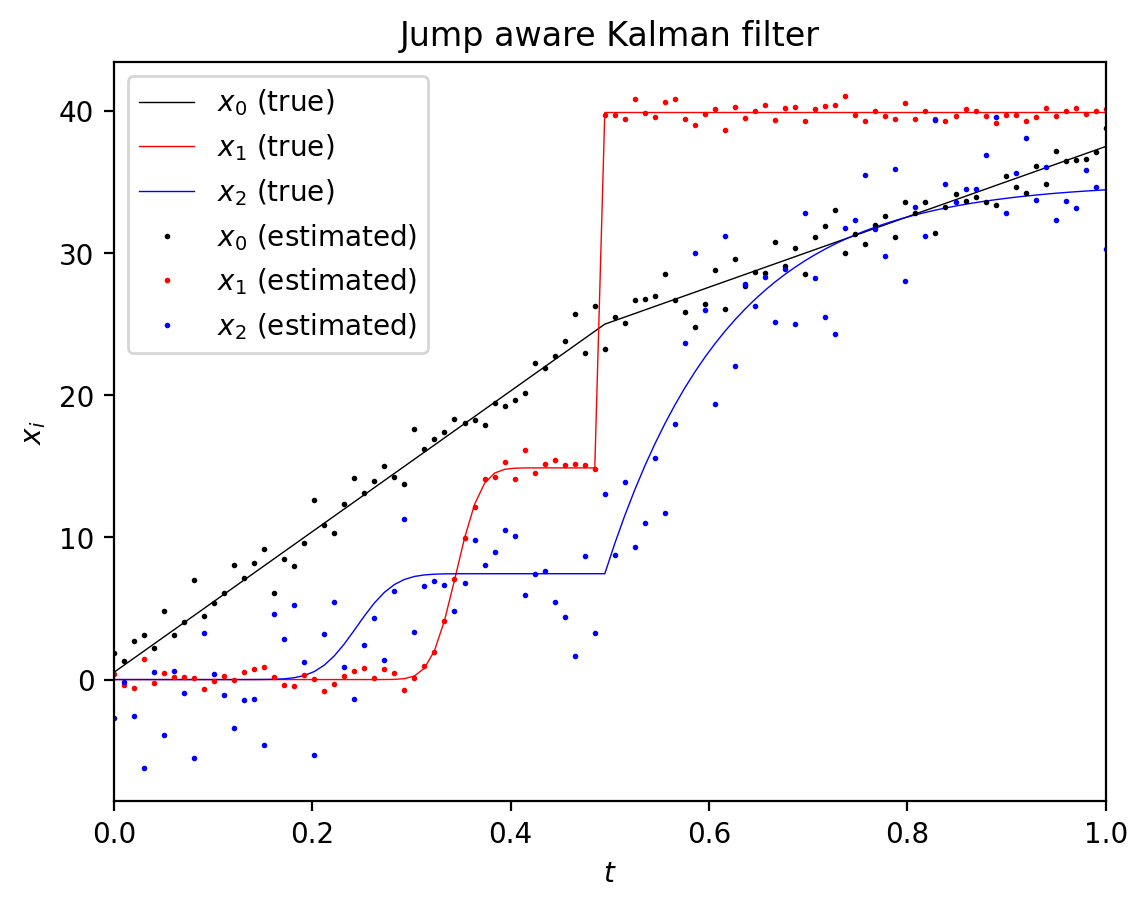

In [12]:
x_estimates, P_estimates, model_probs = imm_filter(t, P_noise.T, A)

plt.figure()
plt.plot(t, x0, "-k", label="$x_0$ (true)", linewidth=linewidth, markersize=markersize)
plt.plot(t, x1, "-r", label="$x_1$ (true)", linewidth=linewidth, markersize=markersize)
plt.plot(t, x2, "-b", label="$x_2$ (true)", linewidth=linewidth, markersize=markersize)
plt.plot(
    t,
    x_estimates[:, 0] / dt,
    ".k",
    label="$x_0$ (estimated)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    t,
    x_estimates[:, 1] / dt,
    ".r",
    label="$x_1$ (estimated)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    t,
    x_estimates[:, 2] / dt,
    ".b",
    label="$x_2$ (estimated)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.xlabel("$t$")
plt.ylabel("$x_i$")
plt.xlim([np.min(t), np.max(t)])
plt.legend()
plt.title("Jump aware Kalman filter")
plt.show()

# Another IMM attempt.  This successful switches states (yay!) but doesn't quite do what I want because it stays in the fast evolving state until the slow state trajectory happens to catch up.  This feels fixable.

Starting filtering with improved jump detection...
Time 0:
  Innovation magnitude: 3.516
  Jump detected: False
Time 10:
  Innovation magnitude: 0.126
  Jump detected: False
Established baseline: 0.144 ± 0.739
Time 20:
  Innovation magnitude: 0.165
  Jump detected: False
Time 30:
  Innovation magnitude: 0.135
  Jump detected: False
Time 40:
  Innovation magnitude: 0.160
  Jump detected: False
Time 50:
  Innovation magnitude: 3.314
  Jump detected: True
JUMP DETECTED at time 50
JUMP DETECTED at time 51
JUMP DETECTED at time 52
JUMP DETECTED at time 53
JUMP DETECTED at time 54
JUMP DETECTED at time 55
JUMP DETECTED at time 56
JUMP DETECTED at time 57
Time 60:
  Innovation magnitude: 2.049
  Jump detected: False
Time 70:
  Innovation magnitude: 1.180
  Jump detected: False
Time 80:
  Innovation magnitude: 0.662
  Jump detected: False
Time 90:
  Innovation magnitude: 0.269
  Jump detected: False
Time 100:
  Innovation magnitude: 3.462
  Jump detected: True
JUMP DETECTED at time 100
JUMP DE

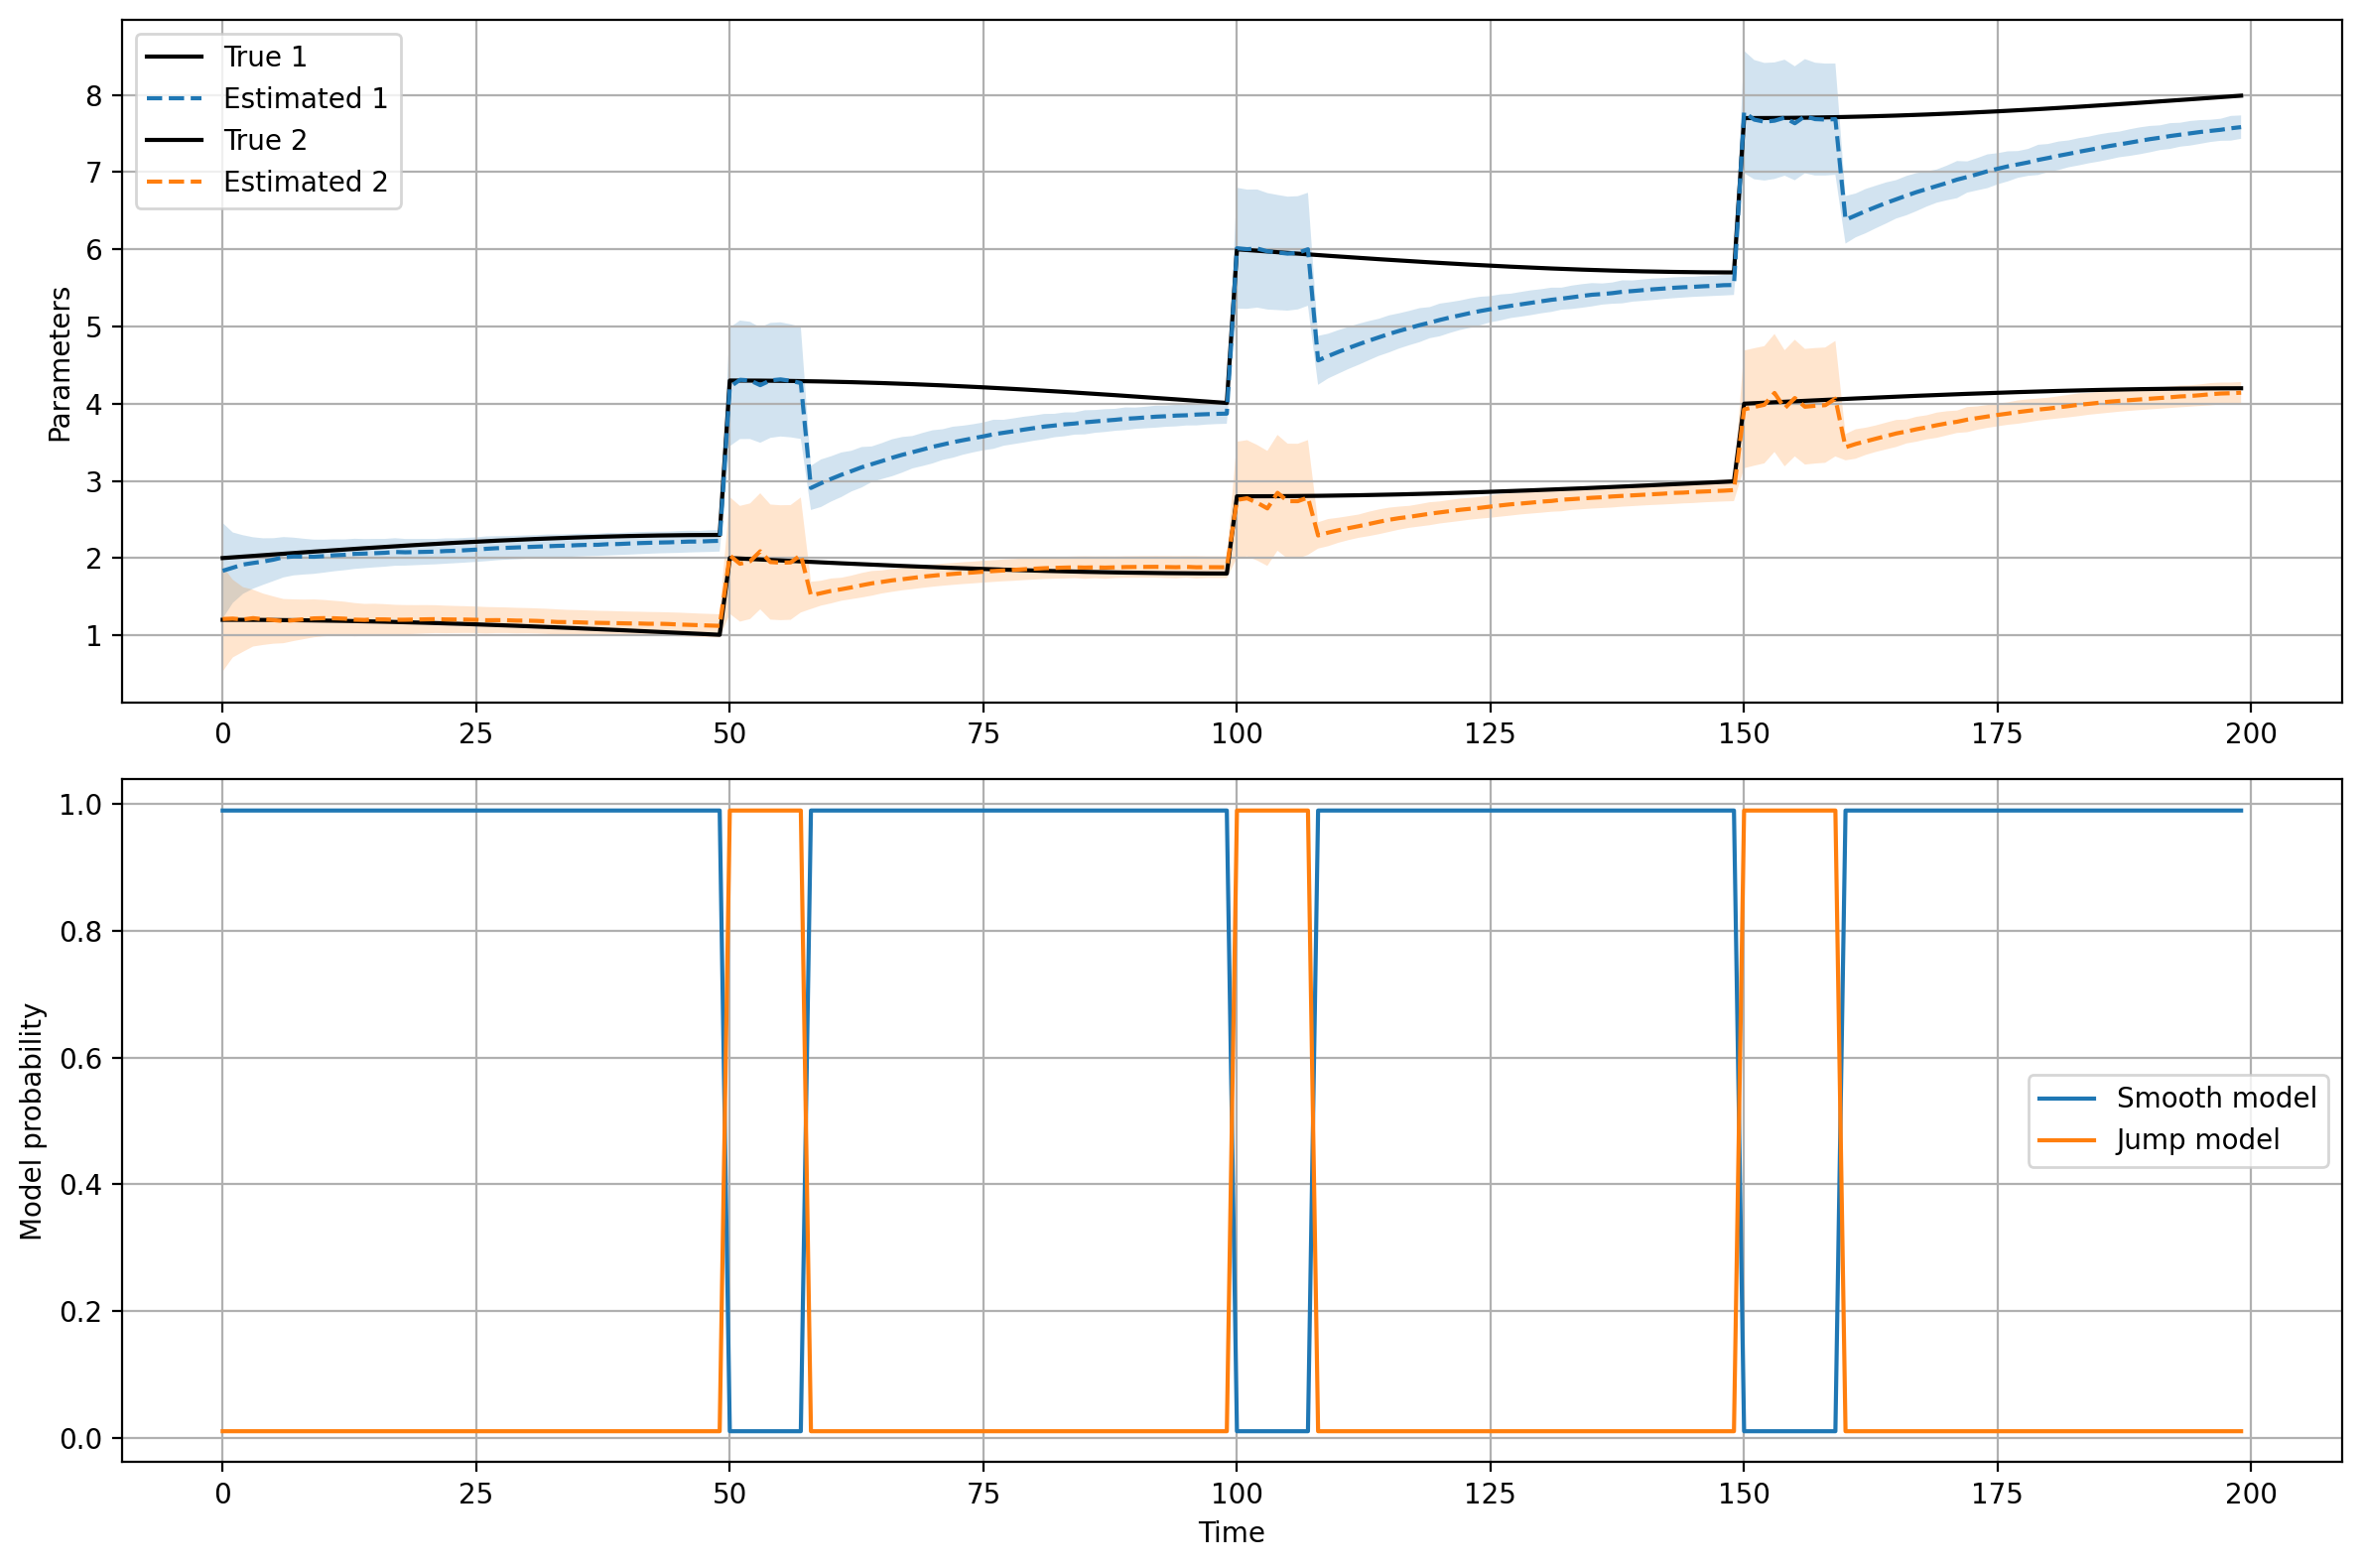

In [21]:
def imm_filter(times, measurements, H, models=2, **kwargs):
    """
    IMM Filter with improved jump detection using fixed reference
    """
    n_times = len(times)
    n_obs = H.shape[0]
    n_states = H.shape[1]

    # Model parameters
    Q1 = np.eye(n_states) * 0.0001
    Q2 = np.eye(n_states) * 1000.0
    Q_models = [Q1, Q2]

    R = kwargs.get("R", np.eye(n_obs) * 0.1)
    x0 = kwargs.get("x0", np.zeros(n_states))
    P0 = kwargs.get("P0", np.eye(n_states))

    # Initialize
    x_models = [x0.copy() for _ in range(models)]
    P_models = [P0.copy() for _ in range(models)]
    model_probs = np.array([0.5, 0.5])

    x_estimates = np.zeros((n_times, n_states))
    P_estimates = np.zeros((n_times, n_states, n_states))
    model_probabilities = np.zeros((n_times, models))

    F = np.eye(n_states)

    # New: Keep track of baseline innovation level
    baseline_innovation = None
    baseline_window = 20  # Window to establish baseline
    innovation_history = []

    print("Starting filtering with improved jump detection...")

    for t, z in enumerate(measurements):
        # Calculate innovations
        innovations_current = []
        for j in range(models):
            pred = H @ (F @ x_models[j])
            innovations_current.append(z - pred)

        current_innovation = np.linalg.norm(innovations_current[0])
        innovation_history.append(current_innovation)

        # Establish baseline if not yet set
        if t < baseline_window:
            if t == baseline_window - 1:
                baseline_innovation = np.median(innovation_history)
                baseline_std = np.std(innovation_history)
                print(
                    f"Established baseline: {baseline_innovation:.3f} ± {baseline_std:.3f}"
                )
            is_jump = False
        else:
            # Detect jumps using fixed baseline reference
            is_jump = current_innovation > (baseline_innovation + 3 * baseline_std)

        if t % 10 == 0:
            print(f"Time {t}:")
            print(f"  Innovation magnitude: {current_innovation:.3f}")
            # print(f"  Baseline: {baseline_innovation:.3f} if established else 'Not yet'")
            print(f"  Jump detected: {is_jump}")

        # More extreme probability adjustment
        if is_jump:
            model_probs = np.array([0.01, 0.99])
            print(f"JUMP DETECTED at time {t}")
        else:
            # Rapid return to smooth model
            model_probs = np.array([0.99, 0.01])

        # Mixing/Interaction
        x_mixed = [np.zeros(n_states) for _ in range(models)]
        P_mixed = [np.zeros((n_states, n_states)) for _ in range(models)]

        for j in range(models):
            x_mixed[j] = x_models[j].copy()
            P_mixed[j] = P_models[j].copy()

        # Model-specific updates
        for j in range(models):
            # Predict
            x_pred = F @ x_mixed[j]
            P_pred = F @ P_mixed[j] @ F.T + Q_models[j]

            # Update
            innovation = z - H @ x_pred
            S = H @ P_pred @ H.T + R
            K = P_pred @ H.T @ inv(S)

            x_models[j] = x_pred + K @ innovation
            P_models[j] = (np.eye(n_states) - K @ H) @ P_pred

        # Combine estimates
        x_combined = np.zeros(n_states)
        P_combined = np.zeros((n_states, n_states))

        for j in range(models):
            x_combined += model_probs[j] * x_models[j]

        for j in range(models):
            diff = x_models[j] - x_combined
            P_combined += model_probs[j] * (P_models[j] + np.outer(diff, diff))

        # Store results
        x_estimates[t] = x_combined
        P_estimates[t] = P_combined
        model_probabilities[t] = model_probs

    return x_estimates, P_estimates, model_probabilities


def example_imm():
    # Generate example data with both smooth regions and jumps
    n_times = 200
    n_states = 2
    n_obs = 3
    times = np.arange(n_times)

    # Generate true parameters with jumps
    true_params = np.zeros((n_times, n_states))

    # Smooth varying parameters with occasional jumps
    base = 2.0 + 0.3 * np.sin(2 * np.pi * times / n_times)
    jumps = np.zeros_like(base)

    # Add more dramatic jumps
    jump_points = [50, 100, 150]
    for jp in jump_points:
        jumps[jp:] += 2.0  # Increased jump size

    true_params[:, 0] = base + jumps
    true_params[:, 1] = 1.0 + 0.2 * np.cos(2 * np.pi * times / n_times) + jumps * 0.5

    # Observation operator
    H = np.array([[1.0, 0.5], [0.3, 1.0], [0.7, 0.2]])

    # Generate measurements with less noise
    measurements = np.zeros((n_times, n_obs))
    for t in range(n_times):
        measurements[t] = H @ true_params[t] + np.random.normal(
            0, 0.05, n_obs
        )  # Reduced noise

    # Run IMM filter
    x_estimates, P_estimates, model_probs = imm_filter(times, measurements, H)

    # Plot results
    import matplotlib.pyplot as plt

    # fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), height_ratios=[3, 1])
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

    # Plot state estimates
    for i in range(n_states):
        ax1.plot(times, true_params[:, i], "k-", label=f"True {i+1}")
        ax1.plot(times, x_estimates[:, i], "--", label=f"Estimated {i+1}")

        std = np.sqrt(P_estimates[:, i, i])
        ax1.fill_between(
            times, x_estimates[:, i] - 2 * std, x_estimates[:, i] + 2 * std, alpha=0.2
        )

    ax1.legend()
    ax1.set_ylabel("Parameters")
    ax1.grid(True)

    # Plot model probabilities
    ax2.plot(times, model_probs[:, 0], label="Smooth model")
    ax2.plot(times, model_probs[:, 1], label="Jump model")
    ax2.set_xlabel("Time")
    ax2.set_ylabel("Model probability")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    return x_estimates, P_estimates, model_probs


if __name__ == "__main__":
    x_estimates, P_estimates, model_probs = example_imm()

Starting filtering with improved jump detection...
Time 0:
  Innovation magnitude: 0.039
  Jump detected: False
Time 10:
  Innovation magnitude: 0.052
  Jump detected: False
Established baseline: 0.053 ± 0.015
Time 20:
  Innovation magnitude: 0.084
  Jump detected: False
JUMP DETECTED at time 23
JUMP DETECTED at time 24
JUMP DETECTED at time 25
JUMP DETECTED at time 26
JUMP DETECTED at time 27
JUMP DETECTED at time 28
JUMP DETECTED at time 29
Time 30:
  Innovation magnitude: 0.147
  Jump detected: True
JUMP DETECTED at time 30
JUMP DETECTED at time 31
JUMP DETECTED at time 32
JUMP DETECTED at time 33
JUMP DETECTED at time 34
JUMP DETECTED at time 35
JUMP DETECTED at time 36
JUMP DETECTED at time 37
JUMP DETECTED at time 38
JUMP DETECTED at time 39
Time 40:
  Innovation magnitude: 0.263
  Jump detected: True
JUMP DETECTED at time 40
JUMP DETECTED at time 41
JUMP DETECTED at time 42
JUMP DETECTED at time 43
JUMP DETECTED at time 44
JUMP DETECTED at time 45
JUMP DETECTED at time 46
JUMP D

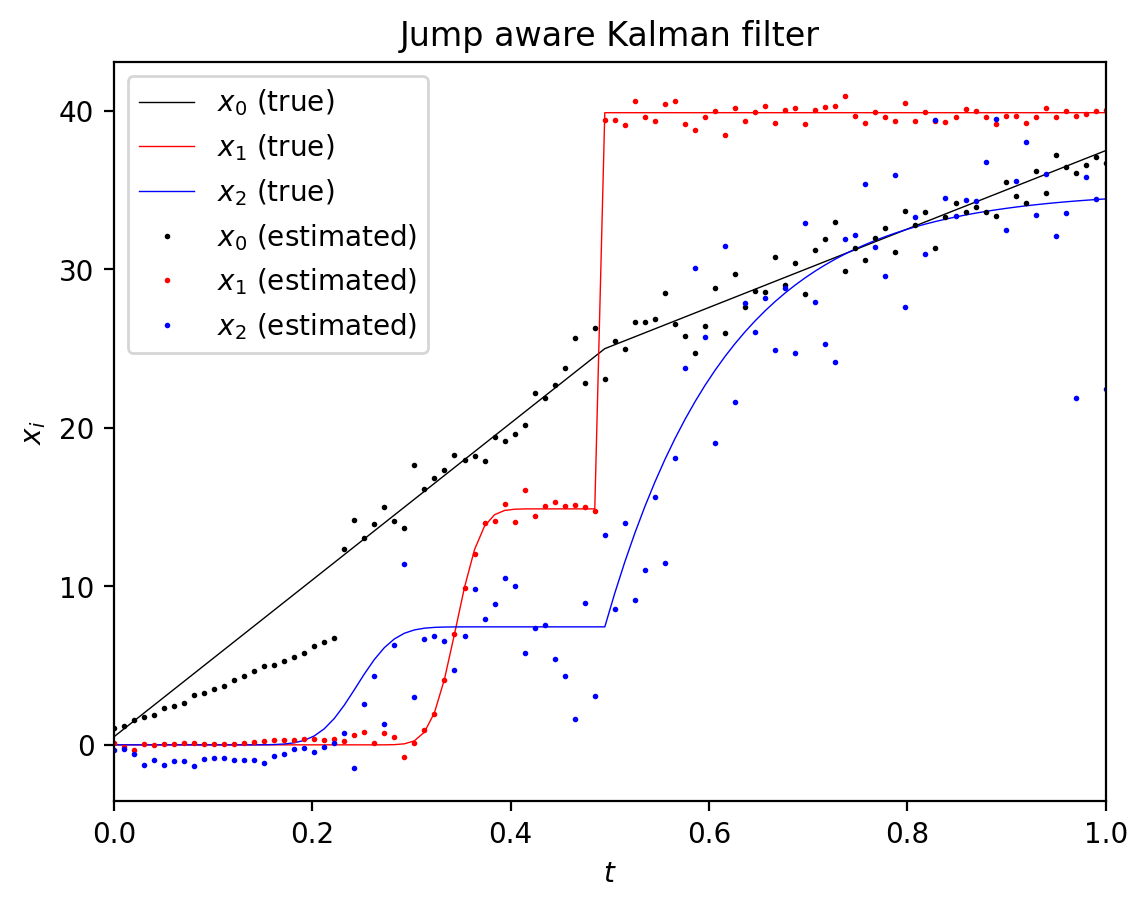

In [22]:
x_estimates, P_estimates, model_probs = imm_filter(t, P_noise.T, A)

plt.figure()
plt.plot(t, x0, "-k", label="$x_0$ (true)", linewidth=linewidth, markersize=markersize)
plt.plot(t, x1, "-r", label="$x_1$ (true)", linewidth=linewidth, markersize=markersize)
plt.plot(t, x2, "-b", label="$x_2$ (true)", linewidth=linewidth, markersize=markersize)
plt.plot(
    t,
    x_estimates[:, 0] / dt,
    ".k",
    label="$x_0$ (estimated)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    t,
    x_estimates[:, 1] / dt,
    ".r",
    label="$x_1$ (estimated)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    t,
    x_estimates[:, 2] / dt,
    ".b",
    label="$x_2$ (estimated)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.xlabel("$t$")
plt.ylabel("$x_i$")
plt.xlim([np.min(t), np.max(t)])
plt.legend()
plt.title("Jump aware Kalman filter")
plt.show()

In [15]:
def imm_filter(times, measurements, H, models=2, **kwargs):
    """
    IMM Filter with improved jump detection and state resetting
    """
    n_times = len(times)
    n_obs = H.shape[0]
    n_states = H.shape[1]

    # Model parameters
    Q1 = np.eye(n_states) * 0.0001
    Q2 = np.eye(n_states) * 1000.0
    Q_models = [Q1, Q2]

    R = kwargs.get("R", np.eye(n_obs) * 0.1)
    x0 = kwargs.get("x0", np.zeros(n_states))
    P0 = kwargs.get("P0", np.eye(n_states))

    # Initialize
    x_models = [x0.copy() for _ in range(models)]
    P_models = [P0.copy() for _ in range(models)]
    model_probs = np.array([0.5, 0.5])

    x_estimates = np.zeros((n_times, n_states))
    P_estimates = np.zeros((n_times, n_states, n_states))
    model_probabilities = np.zeros((n_times, models))

    F = np.eye(n_states)

    # Initialize baseline variables
    baseline_innovation = None
    baseline_std = None
    baseline_window = 20
    innovation_history = []

    # Track previous state for transition detection
    previous_model = 0  # Start in smooth model

    print("Starting filtering with improved jump detection and state resetting...")

    for t, z in enumerate(measurements):
        # Calculate innovations
        innovations_current = []
        for j in range(models):
            pred = H @ (F @ x_models[j])
            innovations_current.append(z - pred)

        current_innovation = np.linalg.norm(innovations_current[0])
        innovation_history.append(current_innovation)

        # Establish baseline if not yet set
        if t < baseline_window:
            if t == baseline_window - 1:
                baseline_innovation = np.median(innovation_history)
                baseline_std = np.std(innovation_history)
                print(
                    f"Established baseline: {baseline_innovation:.3f} ± {baseline_std:.3f}"
                )
            is_jump = False
        else:
            # Detect jumps using fixed baseline reference
            is_jump = current_innovation > (baseline_innovation + 3 * baseline_std)

        if t % 10 == 0:
            print(f"Time {t}:")
            print(f"  Innovation magnitude: {current_innovation:.3f}")
            print(
                f"  Baseline: {baseline_innovation if baseline_innovation is None else f'{baseline_innovation:.3f}'}"
            )
            print(f"  Jump detected: {is_jump}")

        # More extreme probability adjustment
        if is_jump:
            model_probs = np.array([0.01, 0.99])
            current_model = 1
            print(f"JUMP DETECTED at time {t}")
        else:
            # Rapid return to smooth model
            model_probs = np.array([0.99, 0.01])
            current_model = 0

        # Check for transition from jump to smooth
        if previous_model == 1 and current_model == 0:
            print(f"Transitioning from jump to smooth at time {t}")
            # Reset smooth model state to current jump model state
            x_models[0] = x_models[1].copy()
            P_models[0] = P_models[1].copy()

        previous_model = current_model

        # Mixing/Interaction
        x_mixed = [np.zeros(n_states) for _ in range(models)]
        P_mixed = [np.zeros((n_states, n_states)) for _ in range(models)]

        for j in range(models):
            x_mixed[j] = x_models[j].copy()
            P_mixed[j] = P_models[j].copy()

        # Model-specific updates
        for j in range(models):
            # Predict
            x_pred = F @ x_mixed[j]
            P_pred = F @ P_mixed[j] @ F.T + Q_models[j]

            # Update
            innovation = z - H @ x_pred
            S = H @ P_pred @ H.T + R
            K = P_pred @ H.T @ inv(S)

            x_models[j] = x_pred + K @ innovation
            P_models[j] = (np.eye(n_states) - K @ H) @ P_pred

        # Combine estimates
        x_combined = np.zeros(n_states)
        P_combined = np.zeros((n_states, n_states))

        for j in range(models):
            x_combined += model_probs[j] * x_models[j]

        for j in range(models):
            diff = x_models[j] - x_combined
            P_combined += model_probs[j] * (P_models[j] + np.outer(diff, diff))

        # Store results
        x_estimates[t] = x_combined
        P_estimates[t] = P_combined
        model_probabilities[t] = model_probs

    return x_estimates, P_estimates, model_probabilities

# Yet another IMM attempt.  Exhibits switching but still stays in the jump state until the slow state catches up.

Starting filtering with improved jump detection...
Time 0:
  Innovation magnitude: 3.577
  Jump detected: False
Time 10:
  Innovation magnitude: 0.063
  Jump detected: False
Established baseline: 0.119 ± 0.755
Time 20:
  Innovation magnitude: 0.114
  Jump detected: False
Time 30:
  Innovation magnitude: 0.142
  Jump detected: False
Time 40:
  Innovation magnitude: 0.137
  Jump detected: False
Time 50:
  Innovation magnitude: 3.318
  Jump detected: True
JUMP DETECTED at time 50
JUMP DETECTED at time 51
JUMP DETECTED at time 52
JUMP DETECTED at time 53
JUMP DETECTED at time 54
JUMP DETECTED at time 55
JUMP DETECTED at time 56
Time 60:
  Innovation magnitude: 1.993
  Jump detected: False
Time 70:
  Innovation magnitude: 1.162
  Jump detected: False
Time 80:
  Innovation magnitude: 0.605
  Jump detected: False
Time 90:
  Innovation magnitude: 0.315
  Jump detected: False
Time 100:
  Innovation magnitude: 3.430
  Jump detected: True
JUMP DETECTED at time 100
JUMP DETECTED at time 101
JUMP D

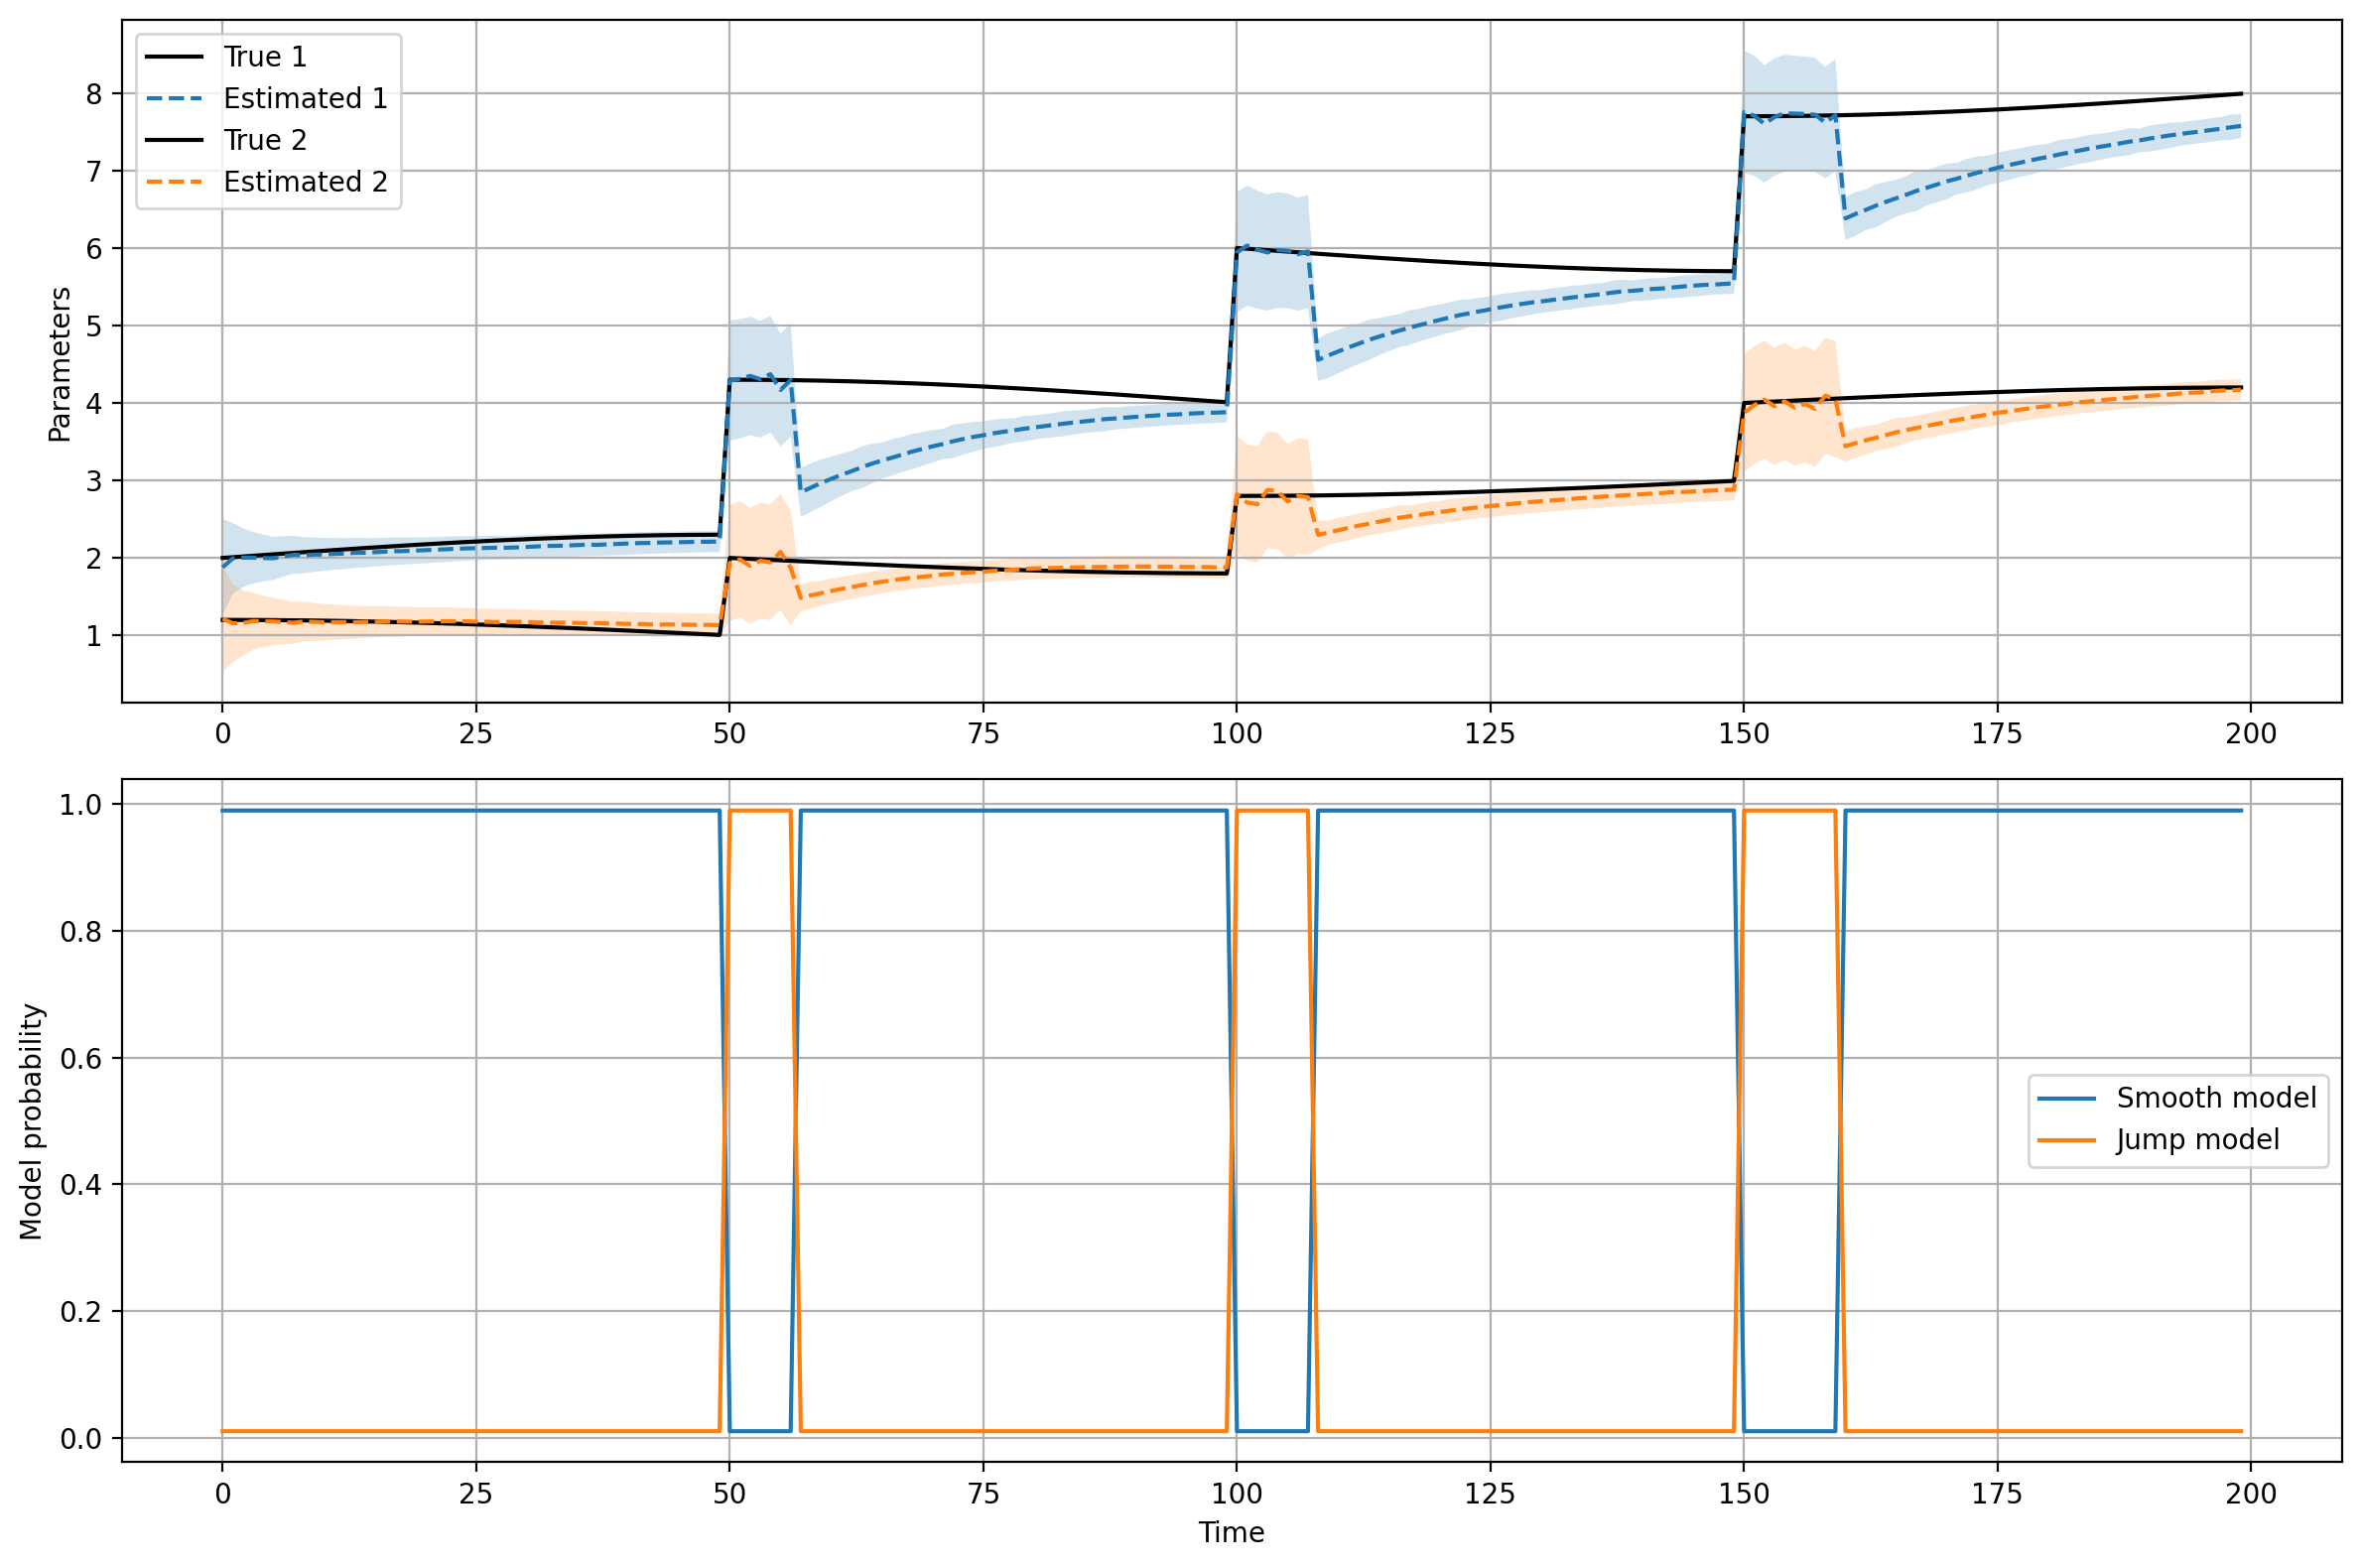

In [23]:
def example_imm():
    # Generate example data with both smooth regions and jumps
    n_times = 200
    n_states = 2
    n_obs = 3
    times = np.arange(n_times)

    # Generate true parameters with jumps
    true_params = np.zeros((n_times, n_states))

    # Smooth varying parameters with occasional jumps
    base = 2.0 + 0.3 * np.sin(2 * np.pi * times / n_times)
    jumps = np.zeros_like(base)

    # Add more dramatic jumps
    jump_points = [50, 100, 150]
    for jp in jump_points:
        jumps[jp:] += 2.0  # Increased jump size

    true_params[:, 0] = base + jumps
    true_params[:, 1] = 1.0 + 0.2 * np.cos(2 * np.pi * times / n_times) + jumps * 0.5

    # Observation operator
    H = np.array([[1.0, 0.5], [0.3, 1.0], [0.7, 0.2]])

    # Generate measurements with less noise
    measurements = np.zeros((n_times, n_obs))
    for t in range(n_times):
        measurements[t] = H @ true_params[t] + np.random.normal(
            0, 0.05, n_obs
        )  # Reduced noise

    # Run IMM filter
    x_estimates, P_estimates, model_probs = imm_filter(times, measurements, H)

    # Plot results
    import matplotlib.pyplot as plt

    # fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), height_ratios=[3, 1])
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

    # Plot state estimates
    for i in range(n_states):
        ax1.plot(times, true_params[:, i], "k-", label=f"True {i+1}")
        ax1.plot(times, x_estimates[:, i], "--", label=f"Estimated {i+1}")

        std = np.sqrt(P_estimates[:, i, i])
        ax1.fill_between(
            times, x_estimates[:, i] - 2 * std, x_estimates[:, i] + 2 * std, alpha=0.2
        )

    ax1.legend()
    ax1.set_ylabel("Parameters")
    ax1.grid(True)

    # Plot model probabilities
    ax2.plot(times, model_probs[:, 0], label="Smooth model")
    ax2.plot(times, model_probs[:, 1], label="Jump model")
    ax2.set_xlabel("Time")
    ax2.set_ylabel("Model probability")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    return x_estimates, P_estimates, model_probs


if __name__ == "__main__":
    x_estimates, P_estimates, model_probs = example_imm()

# Even more IMM.  This looks a bit better tot he eye but it's still staying in the jump state for too long.  This feels very close.

Starting filtering with brief jump states...
Time 0:
  Innovation magnitude: 3.626
  Baseline: None
  Jump detected: False
  Jump timer: 0
Time 10:
  Innovation magnitude: 0.034
  Baseline: None
  Jump detected: False
  Jump timer: 0
Established baseline: 0.121 ± 0.767
Time 20:
  Innovation magnitude: 0.183
  Baseline: 0.121
  Jump detected: True
  Jump timer: 0
JUMP DETECTED at time 20
Transitioning from jump to smooth at time 22
Time 30:
  Innovation magnitude: 0.113
  Baseline: 0.121
  Jump detected: False
  Jump timer: 2
Time 40:
  Innovation magnitude: 0.106
  Baseline: 0.121
  Jump detected: False
  Jump timer: 2
Time 50:
  Innovation magnitude: 3.278
  Baseline: 0.121
  Jump detected: True
  Jump timer: 0
JUMP DETECTED at time 50
Transitioning from jump to smooth at time 56
Time 60:
  Innovation magnitude: 0.112
  Baseline: 0.121
  Jump detected: False
  Jump timer: 2
Time 70:
  Innovation magnitude: 0.090
  Baseline: 0.121
  Jump detected: False
  Jump timer: 2
Time 80:
  Innov

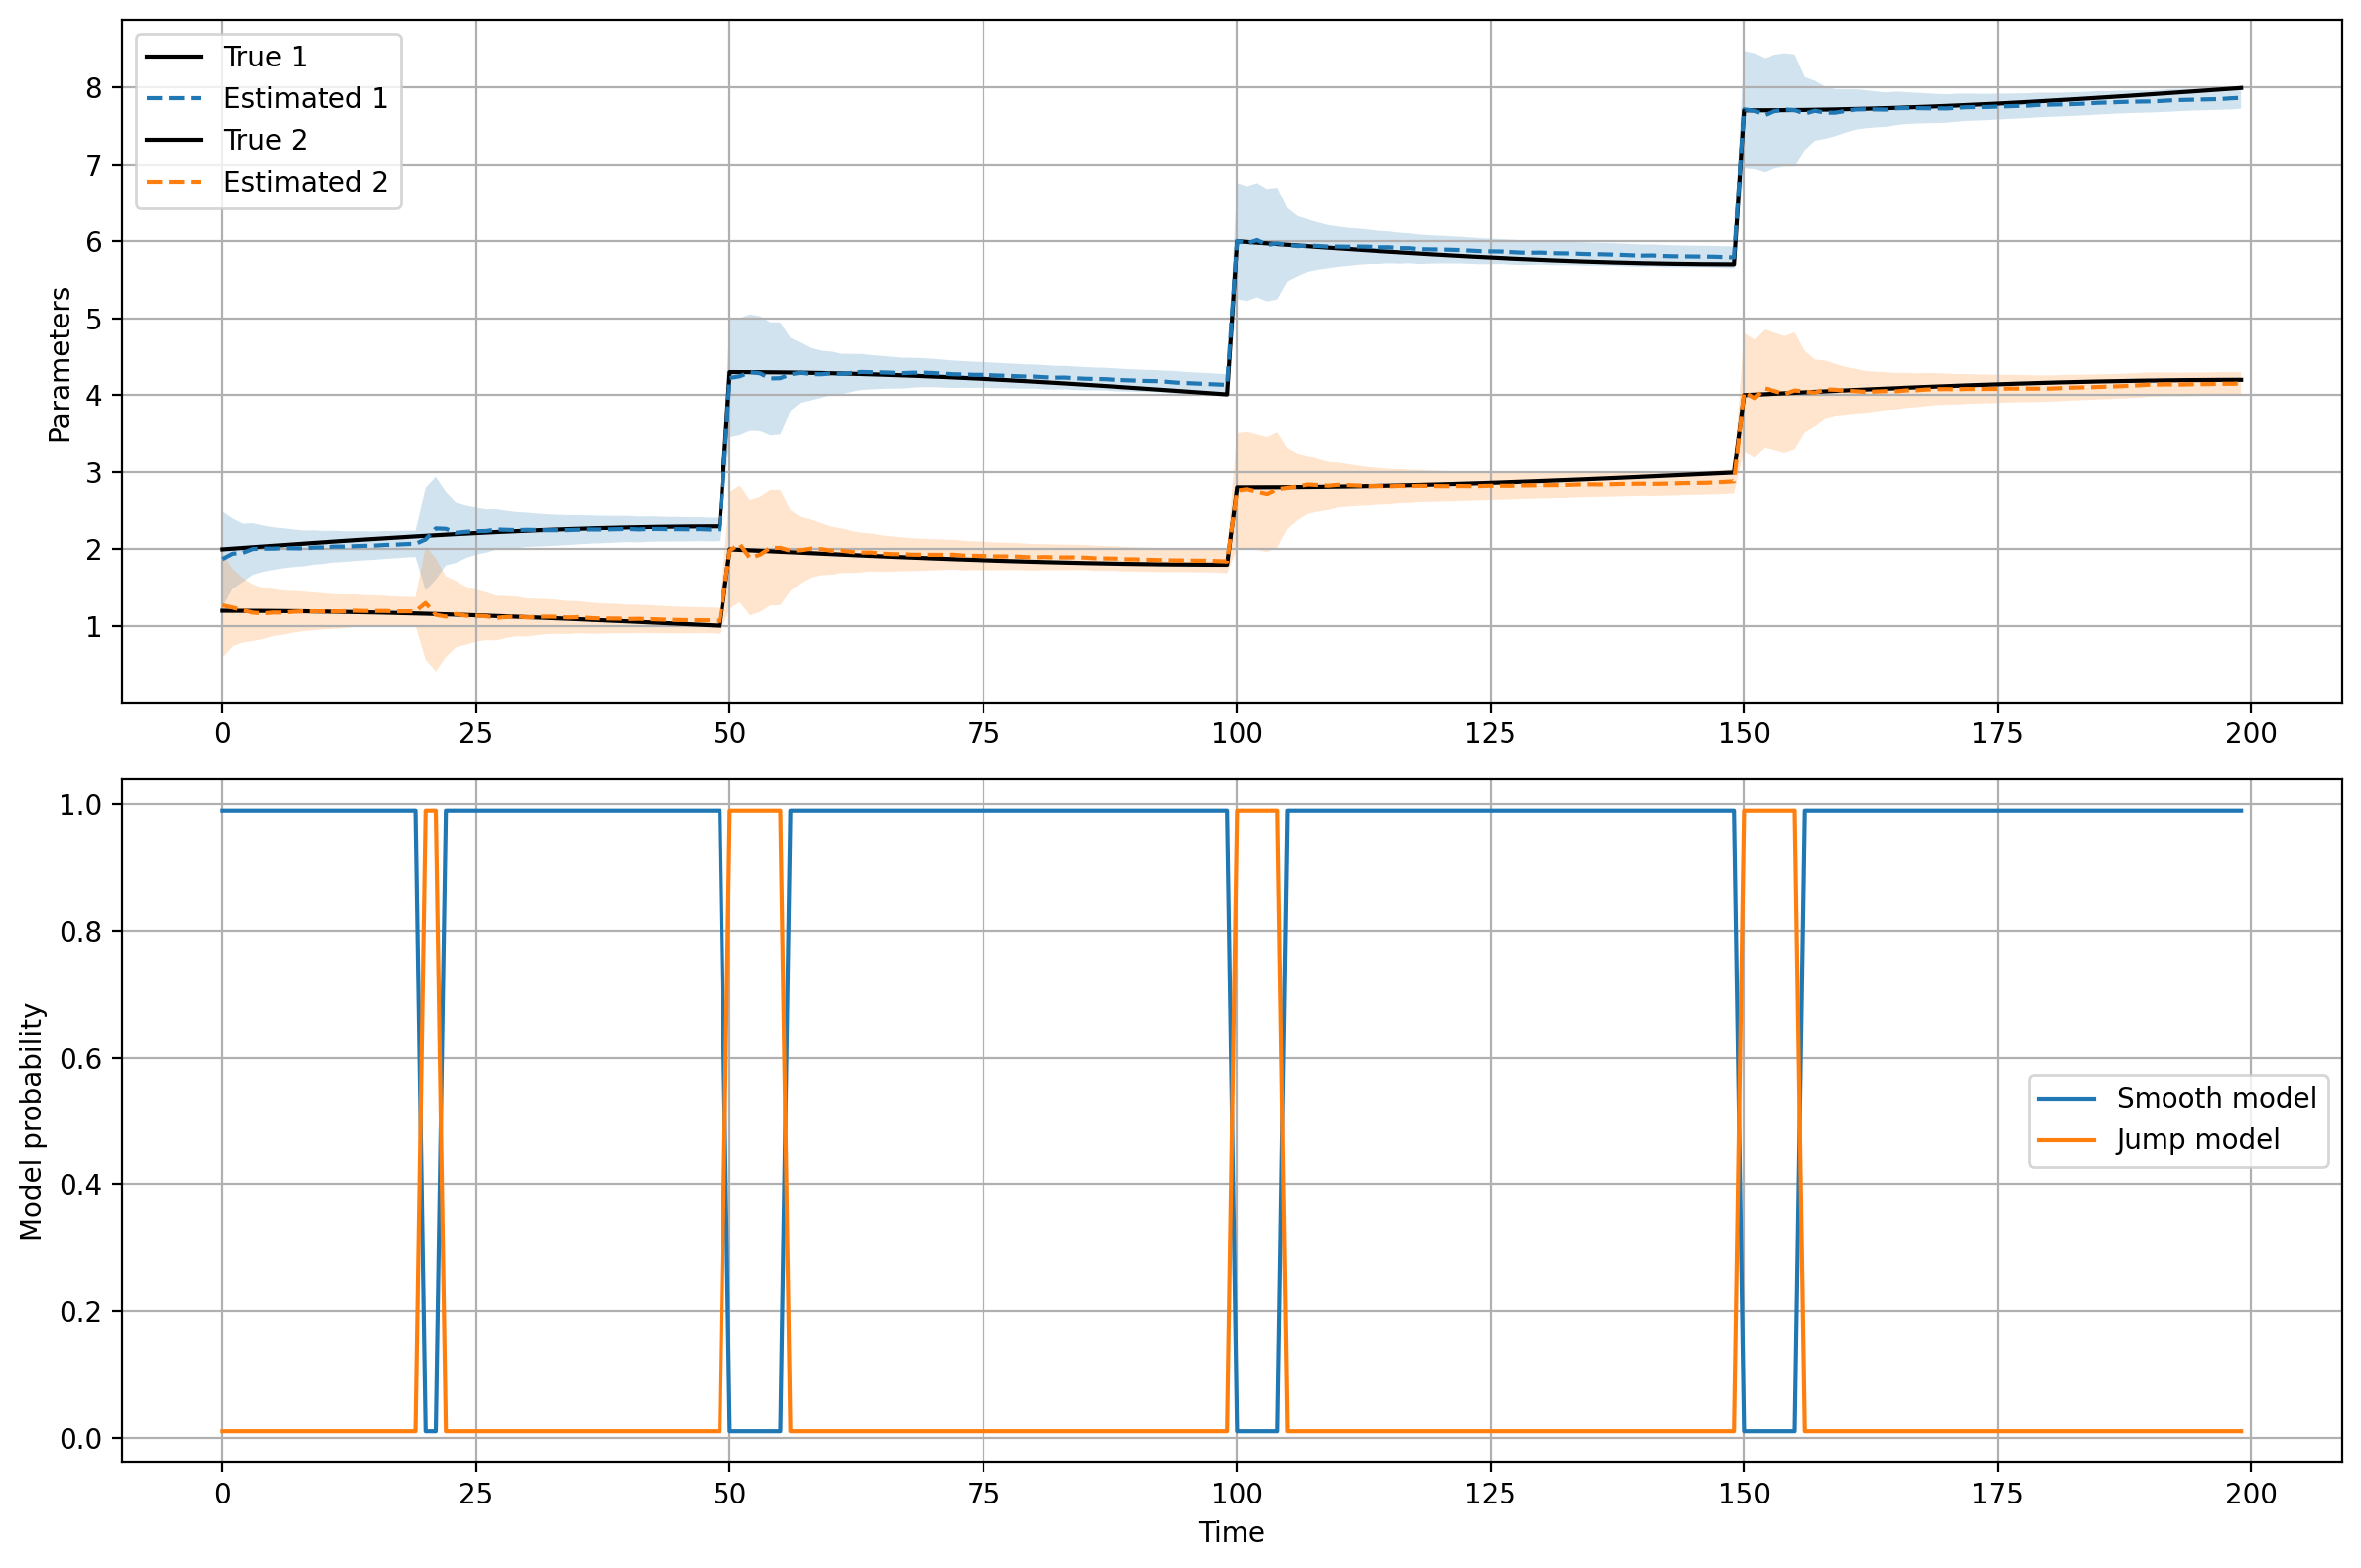

In [26]:
import numpy as np
from scipy.linalg import inv


def imm_filter(times, measurements, H, models=2, **kwargs):
    """
    IMM Filter with improved jump detection and brief jump states
    """
    n_times = len(times)
    n_obs = H.shape[0]
    n_states = H.shape[1]

    # Model parameters
    Q1 = np.eye(n_states) * 0.0001
    Q2 = np.eye(n_states) * 1000.0
    Q_models = [Q1, Q2]

    R = kwargs.get("R", np.eye(n_obs) * 0.1)
    x0 = kwargs.get("x0", np.zeros(n_states))
    P0 = kwargs.get("P0", np.eye(n_states))

    # Initialize
    x_models = [x0.copy() for _ in range(models)]
    P_models = [P0.copy() for _ in range(models)]
    model_probs = np.array([0.5, 0.5])

    x_estimates = np.zeros((n_times, n_states))
    P_estimates = np.zeros((n_times, n_states, n_states))
    model_probabilities = np.zeros((n_times, models))

    F = np.eye(n_states)

    # Initialize baseline variables
    baseline_innovation = None
    baseline_std = None
    baseline_window = 20
    innovation_history = []

    # Track previous state and jump timing
    previous_model = 0
    jump_timer = 0
    max_jump_duration = 2  # Maximum time steps to stay in jump state

    print("Starting filtering with brief jump states...")

    for t, z in enumerate(measurements):
        # Calculate innovations
        innovations_current = []
        for j in range(models):
            pred = H @ (F @ x_models[j])
            innovations_current.append(z - pred)

        current_innovation = np.linalg.norm(innovations_current[0])
        innovation_history.append(current_innovation)

        # Establish baseline if not yet set
        if t < baseline_window:
            if t == baseline_window - 1:
                baseline_innovation = np.median(innovation_history)
                baseline_std = np.std(innovation_history)
                print(
                    f"Established baseline: {baseline_innovation:.3f} ± {baseline_std:.3f}"
                )
            is_jump = False
        else:
            # Detect new jumps using fixed baseline reference
            is_new_jump = current_innovation > (baseline_innovation + 3 * baseline_std)

            # Reset jump timer if new jump detected
            if is_new_jump:
                jump_timer = 0

            # Increment jump timer if in jump state
            if previous_model == 1:
                jump_timer += 1

            # Determine if we should be in jump state
            is_jump = is_new_jump or (jump_timer < max_jump_duration)

        if t % 10 == 0:
            print(f"Time {t}:")
            print(f"  Innovation magnitude: {current_innovation:.3f}")
            print(
                f"  Baseline: {baseline_innovation if baseline_innovation is None else f'{baseline_innovation:.3f}'}"
            )
            print(f"  Jump detected: {is_jump}")
            print(f"  Jump timer: {jump_timer}")

        # Model probability adjustment with forced quick return to smooth
        if is_jump:
            model_probs = np.array([0.01, 0.99])
            current_model = 1
            if jump_timer == 0:  # Only print for new jumps
                print(f"JUMP DETECTED at time {t}")
        else:
            model_probs = np.array([0.99, 0.01])
            current_model = 0

        # Check for transition from jump to smooth
        if previous_model == 1 and current_model == 0:
            print(f"Transitioning from jump to smooth at time {t}")
            # Reset smooth model state to current jump model state
            x_models[0] = x_models[1].copy()
            P_models[0] = P_models[1].copy()

        previous_model = current_model

        # Mixing/Interaction
        x_mixed = [np.zeros(n_states) for _ in range(models)]
        P_mixed = [np.zeros((n_states, n_states)) for _ in range(models)]

        for j in range(models):
            x_mixed[j] = x_models[j].copy()
            P_mixed[j] = P_models[j].copy()

        # Model-specific updates
        for j in range(models):
            # Predict
            x_pred = F @ x_mixed[j]
            P_pred = F @ P_mixed[j] @ F.T + Q_models[j]

            # Update
            innovation = z - H @ x_pred
            S = H @ P_pred @ H.T + R
            K = P_pred @ H.T @ inv(S)

            x_models[j] = x_pred + K @ innovation
            P_models[j] = (np.eye(n_states) - K @ H) @ P_pred

        # Combine estimates
        x_combined = np.zeros(n_states)
        P_combined = np.zeros((n_states, n_states))

        for j in range(models):
            x_combined += model_probs[j] * x_models[j]

        for j in range(models):
            diff = x_models[j] - x_combined
            P_combined += model_probs[j] * (P_models[j] + np.outer(diff, diff))

        # Store results
        x_estimates[t] = x_combined
        P_estimates[t] = P_combined
        model_probabilities[t] = model_probs

    return x_estimates, P_estimates, model_probabilities


def example_imm():
    # Generate example data with both smooth regions and jumps
    n_times = 200
    n_states = 2
    n_obs = 3
    times = np.arange(n_times)

    # Generate true parameters with jumps
    true_params = np.zeros((n_times, n_states))

    # Smooth varying parameters with occasional jumps
    base = 2.0 + 0.3 * np.sin(2 * np.pi * times / n_times)
    jumps = np.zeros_like(base)

    # Add more dramatic jumps
    jump_points = [50, 100, 150]
    for jp in jump_points:
        jumps[jp:] += 2.0  # Increased jump size

    true_params[:, 0] = base + jumps
    true_params[:, 1] = 1.0 + 0.2 * np.cos(2 * np.pi * times / n_times) + jumps * 0.5

    # Observation operator
    H = np.array([[1.0, 0.5], [0.3, 1.0], [0.7, 0.2]])

    # Generate measurements with less noise
    measurements = np.zeros((n_times, n_obs))
    for t in range(n_times):
        measurements[t] = H @ true_params[t] + np.random.normal(
            0, 0.05, n_obs
        )  # Reduced noise

    # Run IMM filter
    x_estimates, P_estimates, model_probs = imm_filter(times, measurements, H)

    # Plot results
    import matplotlib.pyplot as plt

    # fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), height_ratios=[3, 1])
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

    # Plot state estimates
    for i in range(n_states):
        ax1.plot(times, true_params[:, i], "k-", label=f"True {i+1}")
        ax1.plot(times, x_estimates[:, i], "--", label=f"Estimated {i+1}")

        # Plot uncertainty bounds (2 sigma)
        std = np.sqrt(P_estimates[:, i, i])
        ax1.fill_between(
            times, x_estimates[:, i] - 2 * std, x_estimates[:, i] + 2 * std, alpha=0.2
        )

    ax1.legend()
    ax1.set_ylabel("Parameters")
    ax1.grid(True)

    # Plot model probabilities
    ax2.plot(times, model_probs[:, 0], label="Smooth model")
    ax2.plot(times, model_probs[:, 1], label="Jump model")
    ax2.set_xlabel("Time")
    ax2.set_ylabel("Model probability")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    return x_estimates, P_estimates, model_probs


if __name__ == "__main__":
    x_estimates, P_estimates, model_probs = example_imm()

# Particle Filter Time!!!
- Works very well for the synthetic problem
- Results for earthquake problem are poor.  Tweakable.
- Slow

Resampling at t=0, ESS=125.3
Resampling at t=50, ESS=3.3
Resampling at t=100, ESS=8.9
Resampling at t=150, ESS=5.2
Resampling at t=170, ESS=4800.8
Resampling at t=190, ESS=4851.3


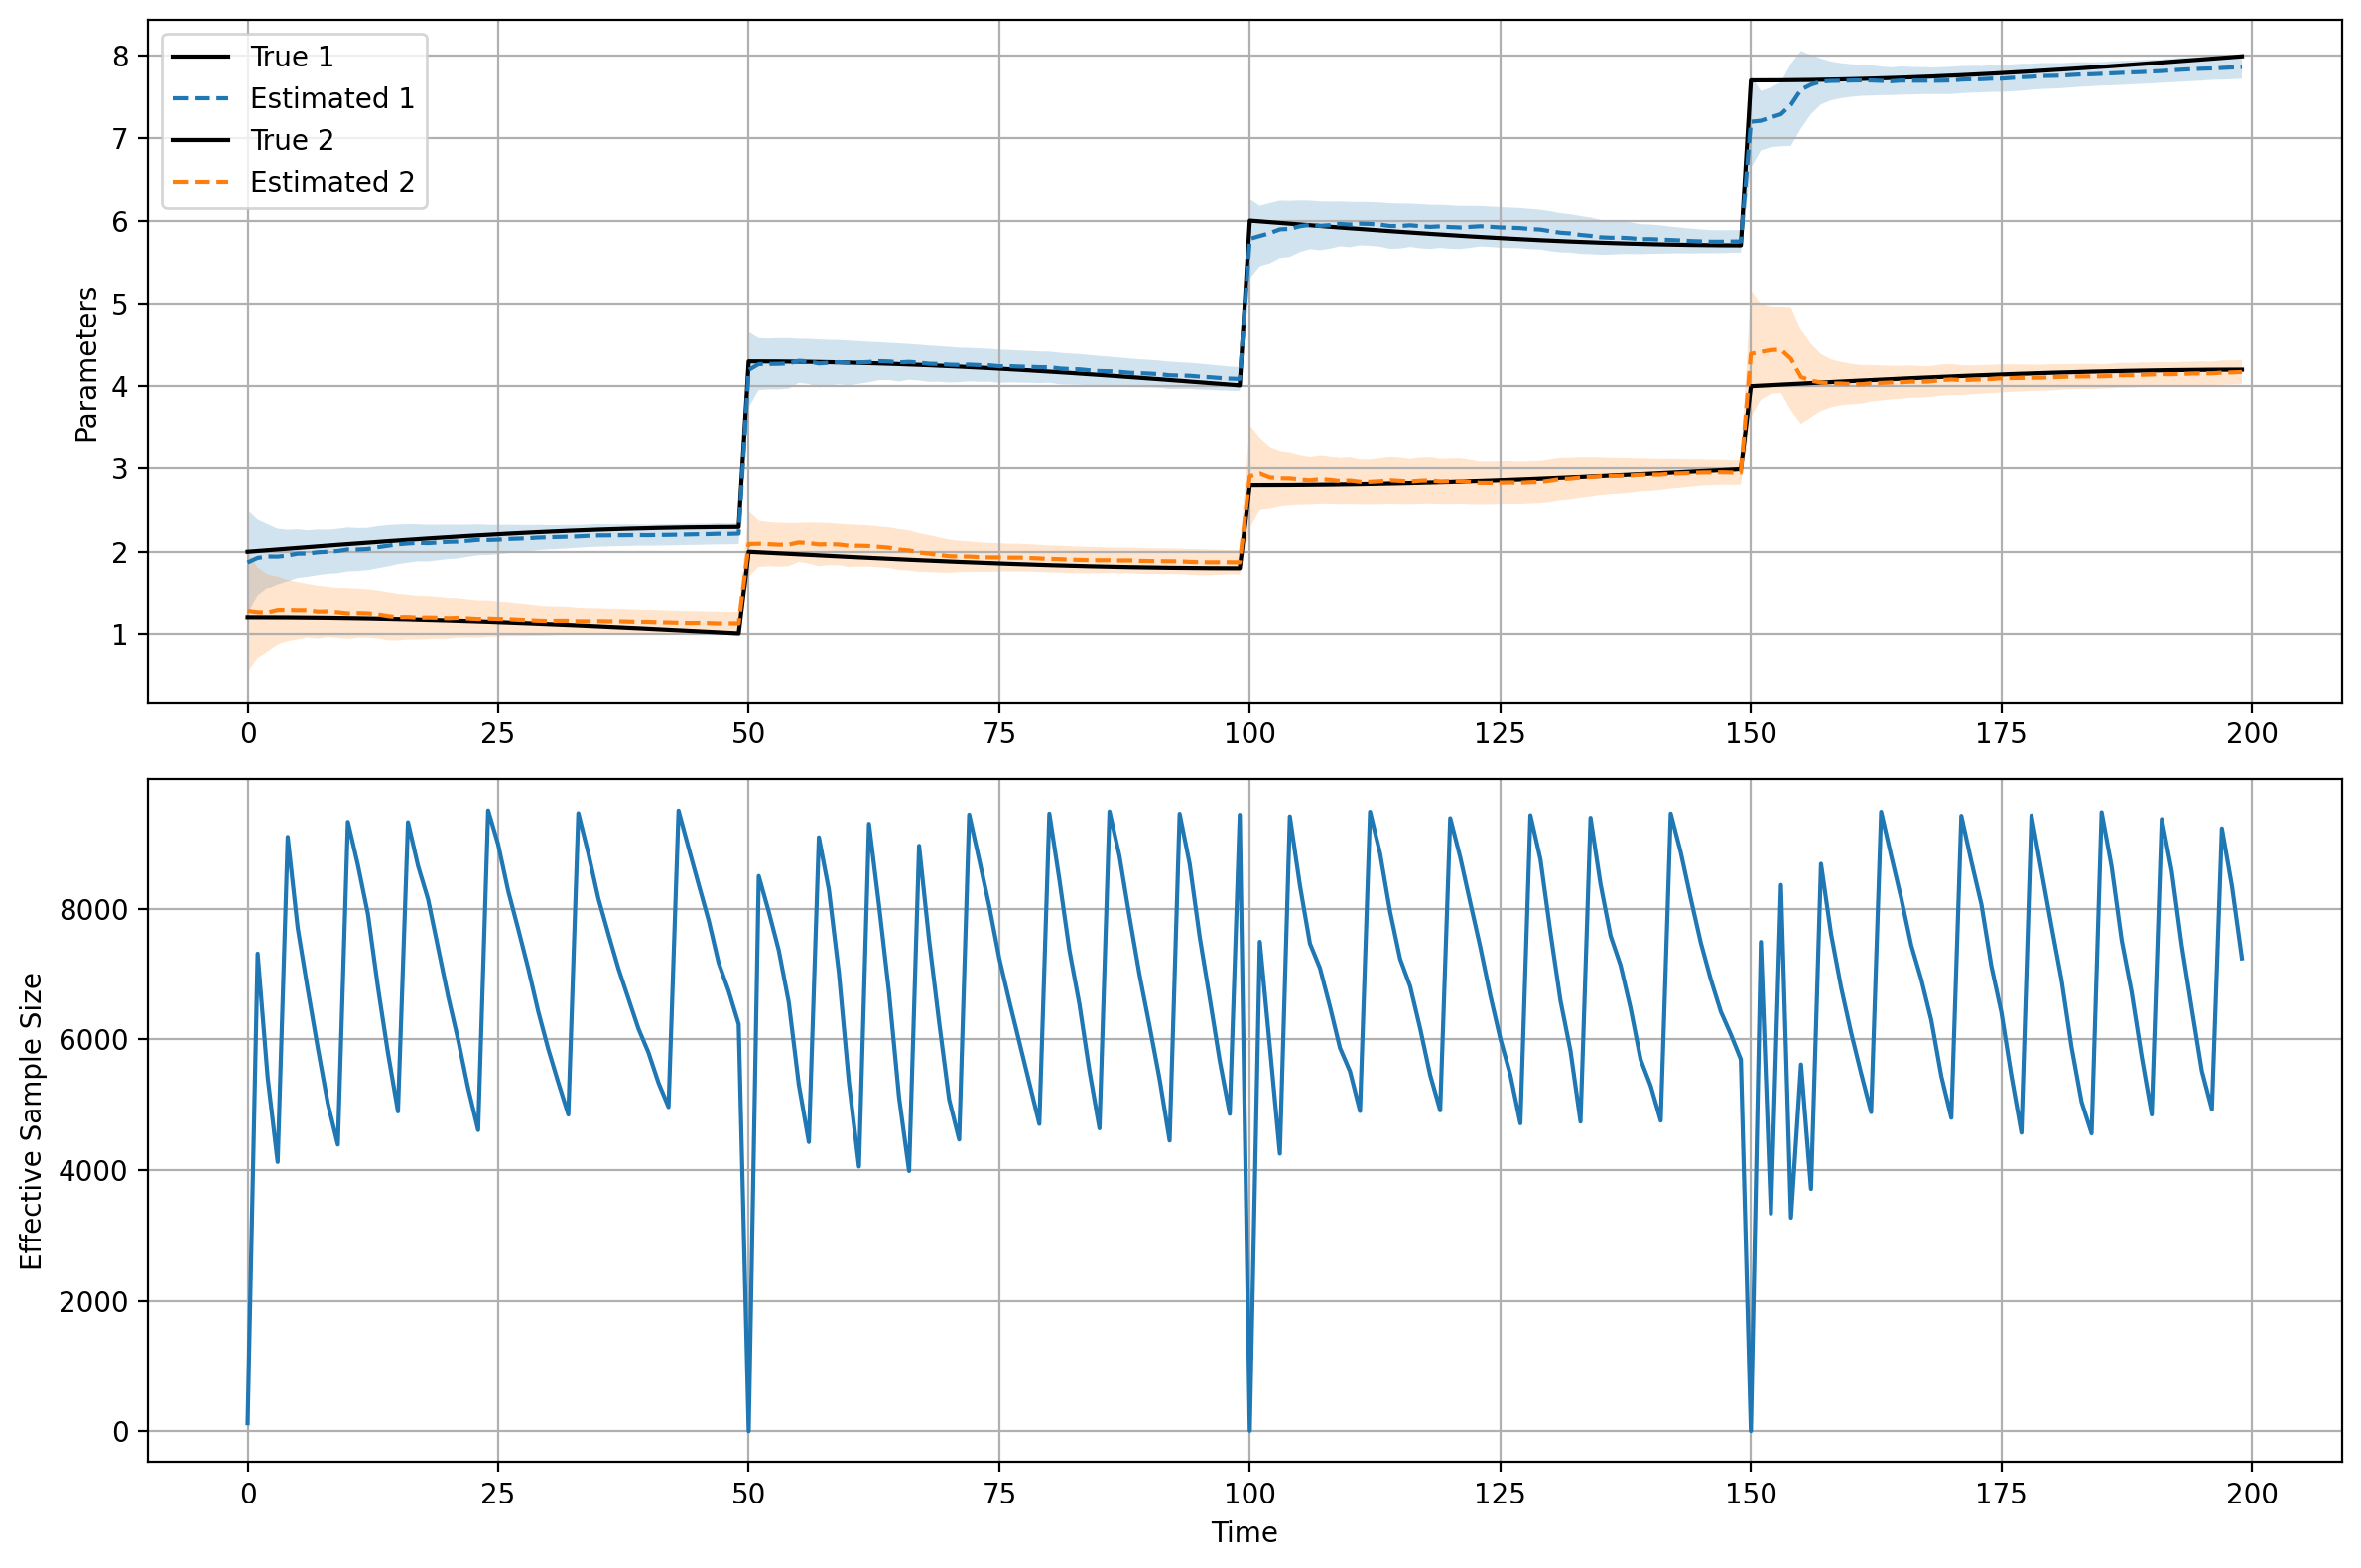

In [28]:
import numpy as np
from scipy.stats import multivariate_normal


def particle_filter(times, measurements, H, n_particles=10000, **kwargs):
    """
    Particle filter with mixed dynamics for smooth evolution and jumps

    Parameters:
    times: array of time points
    measurements: array of measurements (n_times x n_obs)
    H: observation operator (n_obs x n_states)
    n_particles: number of particles to use
    """
    n_times = len(times)
    n_obs = H.shape[0]
    n_states = H.shape[1]

    # Initialize storage
    x_estimates = np.zeros((n_times, n_states))
    P_estimates = np.zeros((n_times, n_states, n_states))

    # Initialize particles and weights
    particles = np.random.normal(0, 1, (n_particles, n_states))
    weights = np.ones(n_particles) / n_particles

    # Noise parameters
    R = kwargs.get("R", np.eye(n_obs) * 0.1)  # Measurement noise
    Q_smooth = np.eye(n_states) * 0.0001  # Smooth evolution noise
    Q_jump = np.eye(n_states) * 1.0  # Jump noise

    # Probability of jump at each timestep
    p_jump = 0.05

    # Measurement likelihood function
    def likelihood(z, x):
        pred = H @ x
        return multivariate_normal.pdf(z, pred, R)

    # Storage for effective sample size history
    ess_history = []

    for t, z in enumerate(measurements):
        # Propagate particles with mixed dynamics
        for i in range(n_particles):
            # Randomly choose between smooth and jump dynamics
            if np.random.random() < p_jump:
                # Jump dynamics
                particles[i] += np.random.multivariate_normal(
                    np.zeros(n_states), Q_jump
                )
            else:
                # Smooth dynamics
                particles[i] += np.random.multivariate_normal(
                    np.zeros(n_states), Q_smooth
                )

        # Update weights based on measurement
        for i in range(n_particles):
            weights[i] *= likelihood(z, particles[i])

        # Normalize weights
        weights /= np.sum(weights)

        # Calculate effective sample size
        ess = 1.0 / np.sum(weights**2)
        ess_history.append(ess)

        # Resample if effective sample size is too low
        if ess < n_particles / 2:
            indices = np.random.choice(n_particles, n_particles, p=weights)
            particles = particles[indices]
            weights = np.ones(n_particles) / n_particles

            if t % 10 == 0:
                print(f"Resampling at t={t}, ESS={ess:.1f}")

        # Calculate estimates
        x_estimates[t] = np.average(particles, weights=weights, axis=0)

        # Calculate weighted covariance
        diff = particles - x_estimates[t]
        P_estimates[t] = np.zeros((n_states, n_states))
        for i in range(n_particles):
            P_estimates[t] += weights[i] * np.outer(diff[i], diff[i])

    return x_estimates, P_estimates, ess_history


def example_particle():
    # Generate example data with both smooth regions and jumps
    n_times = 200
    n_states = 2
    n_obs = 3
    times = np.arange(n_times)

    # Generate true parameters with jumps
    true_params = np.zeros((n_times, n_states))

    # Smooth varying parameters with occasional jumps
    base = 2.0 + 0.3 * np.sin(2 * np.pi * times / n_times)
    jumps = np.zeros_like(base)

    # Add jumps
    jump_points = [50, 100, 150]
    for jp in jump_points:
        jumps[jp:] += 2.0

    true_params[:, 0] = base + jumps
    true_params[:, 1] = 1.0 + 0.2 * np.cos(2 * np.pi * times / n_times) + jumps * 0.5

    # Observation operator
    H = np.array([[1.0, 0.5], [0.3, 1.0], [0.7, 0.2]])

    # Generate measurements
    measurements = np.zeros((n_times, n_obs))
    for t in range(n_times):
        measurements[t] = H @ true_params[t] + np.random.normal(0, 0.05, n_obs)

    # Run particle filter
    x_estimates, P_estimates, ess_history = particle_filter(times, measurements, H)

    # Plot results
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

    # Plot state estimates
    for i in range(n_states):
        ax1.plot(times, true_params[:, i], "k-", label=f"True {i+1}")
        ax1.plot(times, x_estimates[:, i], "--", label=f"Estimated {i+1}")

        # Plot uncertainty bounds (2 sigma)
        std = np.sqrt(P_estimates[:, i, i])
        ax1.fill_between(
            times, x_estimates[:, i] - 2 * std, x_estimates[:, i] + 2 * std, alpha=0.2
        )

    ax1.legend()
    ax1.set_ylabel("Parameters")
    ax1.grid(True)

    # Plot effective sample size
    ax2.plot(times, ess_history)
    ax2.set_xlabel("Time")
    ax2.set_ylabel("Effective Sample Size")
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    return x_estimates, P_estimates, ess_history


if __name__ == "__main__":
    x_estimates, P_estimates, ess_history = example_particle()

In [ ]:
x_estimates, P_estimates, ess_history = particle_filter(
    t, P_true_mod.T, A, n_particles=1000
)

plt.figure()
plt.plot(t, x0, "-k", label="$x_0$ (true)", linewidth=linewidth, markersize=markersize)
plt.plot(t, x1, "-r", label="$x_1$ (true)", linewidth=linewidth, markersize=markersize)
plt.plot(t, x2, "-b", label="$x_2$ (true)", linewidth=linewidth, markersize=markersize)
plt.plot(
    t,
    x_estimates[:, 0] / dt,
    ".k",
    label="$x_0$ (estimated)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    t,
    x_estimates[:, 1] / dt,
    ".r",
    label="$x_1$ (estimated)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    t,
    x_estimates[:, 2] / dt,
    ".b",
    label="$x_2$ (estimated)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.xlabel("$t$")
plt.ylabel("$x_i$")
plt.xlim([np.min(t), np.max(t)])
plt.legend()
plt.title("Jump aware Kalman filter")
plt.show()

# What about a Kalman filter but we take out all of the coseismic jumps ahead of time?

In [ ]:
P_true_mod = np.copy(P_true)
P_noise_mod = np.copy(P_noise)
x1_mod = np.copy(x1)
coseismic_step = x1_mod[coseismic_idx] - x1_mod[coseismic_idx - 1]
x1_mod[coseismic_idx::] -= coseismic_step


for i in range(n_pts):
    # Remove coseismic from noise free observations
    coseismic_step = P_true_mod[i, coseismic_idx] - P_true_mod[i, coseismic_idx - 1]
    P_true_mod[i, coseismic_idx::] -= coseismic_step

    # Remove coseismic from noisy observations
    coseismic_step = P_noise_mod[i, coseismic_idx] - P_noise_mod[i, coseismic_idx - 1]
    P_noise_mod[i, coseismic_idx::] -= coseismic_step

# Plot synthetic data
plt.figure(figsize=(12, 4))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
plt.subplot(1, 2, 1)
for i in range(len(plot_idx)):
    plt.plot(
        t,
        P_true[plot_idx[i], :],
        "-",
        linewidth=linewidth,
        markersize=markersize,
        color=colors[i],
    )
    plt.plot(
        t,
        P_noise[plot_idx[i], :],
        ".",
        linewidth=linewidth,
        markersize=markersize,
        color=colors[i],
    )
plt.xlabel("$t$")
plt.ylabel("$\Delta p$")
plt.xlim([np.min(t), np.max(t)])
plt.ylim([-0.5, 0.5])
plt.title("synthetic data")

plt.subplot(1, 2, 2)
for i in range(len(plot_idx)):
    plt.plot(
        t,
        P_true_mod[plot_idx[i], :],
        "-",
        linewidth=linewidth,
        markersize=markersize,
        color=colors[i],
    )
    plt.plot(
        t,
        P_noise_mod[plot_idx[i], :],
        ".",
        linewidth=linewidth,
        markersize=markersize,
        color=colors[i],
    )
plt.xlabel("$t$")
plt.ylabel("$\Delta p$")
plt.xlim([np.min(t), np.max(t)])
plt.ylim([-0.5, 0.5])
plt.title("synthetic data - coseismic removed")

plt.show()

In [ ]:
def constrained_kalman_filter(times, measurements, H, Q=None, R=None, x0=None, P0=None):
    """
    Kalman filter with non-negative least squares constraint for parameter estimation

    Parameters:
    times: array of time points
    measurements: array of measurements (n_times x n_obs)
    H: observation operator (n_obs x n_states)
    Q: process noise covariance (n_states x n_states)
    R: measurement noise covariance (n_obs x n_obs)
    x0: initial state estimate (n_states)
    P0: initial state covariance (n_states x n_states)
    """
    n_times = len(times)
    n_obs = H.shape[0]
    n_states = H.shape[1]

    # Set defaults if not provided
    if Q is None:
        Q = np.eye(n_states) * 0.1
    if R is None:
        R = np.eye(n_obs) * 2.001
    if x0 is None:
        x0 = np.zeros(n_states)
    if P0 is None:
        P0 = np.eye(n_states)

    # State transition matrix (identity for random walk)
    F = np.eye(n_states)

    # Storage for estimates
    x_estimates = np.zeros((n_times, n_states))
    P_estimates = np.zeros((n_times, n_states, n_states))

    # Initialize
    x = x0
    P = P0

    # Run filter through time
    for t, z in enumerate(measurements):
        # Predict
        x = F @ x
        P = F @ P @ F.T + Q  # Fixed: correct matrix multiplication

        # Construct weighted least squares problem for the update
        # Transform to standard form incorporating prior
        Rinv_sqrt = inv(np.linalg.cholesky(R))
        Pinv_sqrt = inv(np.linalg.cholesky(P))

        # Stack matrices for the constrained problem
        A_stack = np.vstack([Rinv_sqrt @ H, Pinv_sqrt])

        b_stack = np.concatenate([Rinv_sqrt @ z, Pinv_sqrt @ x])

        # Solve constrained problem with nnls
        x, residual = nnls(A_stack, b_stack)

        # Approximate posterior covariance
        # (using linearized measurement update)
        S = H @ P @ H.T + R
        K = P @ H.T @ inv(S)
        P = (np.eye(n_states) - K @ H) @ P

        # Store estimates
        x_estimates[t] = x
        P_estimates[t] = P

    return x_estimates, P_estimates


x_estimates, P_estimates = constrained_kalman_filter(t, P_noise_noco.T, A)

plt.figure()
plt.plot(t, x0, "-k", label="$x_0$ (true)", linewidth=linewidth, markersize=markersize)
plt.plot(
    t, x1_noco, "-r", label="$x_1$ (true)", linewidth=linewidth, markersize=markersize
)
plt.plot(t, x2, "-b", label="$x_2$ (true)", linewidth=linewidth, markersize=markersize)


# i = 0
# std = np.sqrt(P_estimates[:, i, i])
# plt.fill_between(
#     t,
#     x_estimates[:, i] / dt - 2 * std,
#     x_estimates[:, i] / dt + 2 * std,
#     alpha=0.2,
#     color="k",
#     edgecolor=None,
# )
plt.plot(
    t,
    x_estimates[:, 0] / dt,
    ".k",
    label="$x_0$ (estimated)",
    linewidth=linewidth,
    markersize=markersize,
)


# i = 1
# std = np.sqrt(P_estimates[:, i, i])
# plt.fill_between(
#     t,
#     x_estimates[:, i] / dt - 2 * std,
#     x_estimates[:, i] / dt + 2 * std,
#     alpha=0.2,
#     color="r",
#     edgecolor=None,
# )
plt.plot(
    t,
    x_estimates[:, 1] / dt,
    ".r",
    label="$x_1$ (estimated)",
    linewidth=linewidth,
    markersize=markersize,
)


# i = 2
# std = np.sqrt(P_estimates[:, i, i])
# plt.fill_between(
#     t,
#     x_estimates[:, i] / dt - 2 * std,
#     x_estimates[:, i] / dt + 2 * std,
#     alpha=0.2,
#     color="b",
#     edgecolor=None,
# )
plt.plot(
    t,
    x_estimates[:, 2] / dt,
    ".b",
    label="$x_2$ (estimated)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.xlabel("$t$")
plt.ylabel("$x_i$")
plt.xlim([np.min(t), np.max(t)])
plt.legend()
plt.title("Constrained Kalman filter")
plt.show()